# Whole image quality control metric evaluation

In this notebook, we will use the QC metrics developing threshold using coSMicQC for the blur metric.

**Blur metric to detect out of focus images** -> PowerLogLogSlope

We will use CytoDataFrame to visualize which images will fail QC if we set a threshold of 1% of pixels at the max intensity.

**Saturation metric to detect large smudges or oversaturation** -> PercentMaximal

## Import libraries

In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cosmicqc import find_outliers, identify_outliers
from cytodataframe import CytoDataFrame


## Set paths and load in data frame

In [2]:
# Directory for figures to be outputted
figure_dir = pathlib.Path("./qc_figures")
figure_dir.mkdir(exist_ok=True)

# Directory with QC CellProfiler outputs per plate
qc_results_dir = pathlib.Path("./whole_img_qc_output")

# Create an empty dictionary to store data frames for each plate
all_qc_data_frames = {}

# List all plate directories within the qc_results_dir
plates = [plate.name for plate in qc_results_dir.iterdir() if plate.is_dir()]

# Loop through each plate
for plate in plates:
    # Read in CSV with all image quality metrics per image for the current plate
    qc_df = pd.read_csv(qc_results_dir / plate / "Image.csv")

    # Store the data frame for the current plate in the dictionary
    all_qc_data_frames[plate] = qc_df

# Print the plate names to ensure they were loaded correctly
print(all_qc_data_frames.keys())

# Concatenate all plate dataframes into a single DataFrame, keeping track of the plate
orig_df = pd.concat(
    [df.assign(Metadata_Plate=plate) for plate, df in all_qc_data_frames.items()],
    ignore_index=True,
)

# Quick check
print(orig_df.shape)
orig_df.head()

# Optional: select the first plate for an example
first_plate = plates[0]
print(f"Showing example for the first plate: {first_plate}")
example_df = all_qc_data_frames[first_plate]
print(example_df.shape)
example_df.head()


dict_keys(['BR00150699', 'BR00150701', 'BR00150700', 'BR00150703', 'BR00150696', 'BR00150698', 'BR00150702', 'BR00150697', 'BR00150695'])
(8423, 82)
Showing example for the first plate: BR00150699
(864, 82)


,ExecutionTime_01LoadData,ExecutionTime_02MeasureImageQuality,FileName_OrigAGP,FileName_OrigDNA,FileName_OrigER,FileName_OrigMito,FileName_OrigRNA,Group_Index,Group_Length,Group_Number,...,URL_OrigAGP,URL_OrigDNA,URL_OrigER,URL_OrigMito,URL_OrigRNA,Width_OrigAGP,Width_OrigDNA,Width_OrigER,Width_OrigMito,Width_OrigRNA
0,2.79,4.63,r03c03f01p01-ch3sk1fk1fl1.tiff,r03c03f01p01-ch5sk1fk1fl1.tiff,r03c03f01p01-ch2sk1fk1fl1.tiff,r03c03f01p01-ch4sk1fk1fl1.tiff,r03c03f01p01-ch6sk1fk1fl1.tiff,1,864,1,...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,1080,1080,1080,1080,1080
1,1.55,3.58,r03c03f02p01-ch3sk1fk1fl1.tiff,r03c03f02p01-ch5sk1fk1fl1.tiff,r03c03f02p01-ch2sk1fk1fl1.tiff,r03c03f02p01-ch4sk1fk1fl1.tiff,r03c03f02p01-ch6sk1fk1fl1.tiff,2,864,1,...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,1080,1080,1080,1080,1080
2,2.01,3.53,r03c03f03p01-ch3sk1fk1fl1.tiff,r03c03f03p01-ch5sk1fk1fl1.tiff,r03c03f03p01-ch2sk1fk1fl1.tiff,r03c03f03p01-ch4sk1fk1fl1.tiff,r03c03f03p01-ch6sk1fk1fl1.tiff,3,864,1,...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,1080,1080,1080,1080,1080
3,0.57,3.27,r03c03f04p01-ch3sk1fk1fl1.tiff,r03c03f04p01-ch5sk1fk1fl1.tiff,r03c03f04p01-ch2sk1fk1fl1.tiff,r03c03f04p01-ch4sk1fk1fl1.tiff,r03c03f04p01-ch6sk1fk1fl1.tiff,4,864,1,...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,1080,1080,1080,1080,1080
4,0.95,3.10,r03c03f05p01-ch3sk1fk1fl1.tiff,r03c03f05p01-ch5sk1fk1fl1.tiff,r03c03f05p01-ch2sk1fk1fl1.tiff,r03c03f05p01-ch4sk1fk1fl1.tiff,r03c03f05p01-ch6sk1fk1fl1.tiff,5,864,1,...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,file:/home/jenna/mnt/bandicoot/PCCMA_data/Atla...,1080,1080,1080,1080,1080


## Create concat data frames combining blur and saturation metrics from all channels for all plates

In [3]:
# List of channels (excluding Brightfield since the metrics are not robust to this type of channel)
channels = ["OrigDNA", "OrigER", "OrigAGP", "OrigMito", "OrigRNA"]

# Create an empty dictionary to store data frames for each channel
all_combined_dfs = {}

# Iterate through each channel
for channel in channels:
    # Create an empty list to store data frames for each plate
    plate_dfs = []

    # Iterate through each plate and create the specified data frame for the channel
    for plate, qc_df in all_qc_data_frames.items():
        plate_df = qc_df.filter(like="Metadata_").copy()

        # Add PowerLogLogSlope column (blur metric)
        plate_df["ImageQuality_PowerLogLogSlope"] = qc_df[
            f"ImageQuality_PowerLogLogSlope_{channel}"
        ]

        # Add PercentMaximal column (saturation metric)
        plate_df["ImageQuality_PercentMaximal"] = qc_df[
            f"ImageQuality_PercentMaximal_{channel}"
        ]

        # Add "Channel" column
        plate_df["Channel"] = channel

        # Add "Metadata_Plate" column
        plate_df["Metadata_Plate"] = plate

        # Append the data frame to the list
        plate_dfs.append(plate_df)

    # Concatenate data frames for each plate for the current channel
    all_combined_dfs[channel] = pd.concat(
        plate_dfs, keys=list(all_qc_data_frames.keys()), names=["Metadata_Plate", None]
    )

# Concatenate the channel data frames together for plotting
df = pd.concat(list(all_combined_dfs.values()), ignore_index=True)

print(df.shape)
df.head()


(42115, 12)


,Metadata_Col,Metadata_FieldID,Metadata_PlaneID,Metadata_Plate,Metadata_PositionX,Metadata_PositionY,Metadata_Row,Metadata_Site,Metadata_Well,ImageQuality_PowerLogLogSlope,ImageQuality_PercentMaximal,Channel
0,3,1,1,BR00150699,0.000000,0.000000,3,1,C03,-1.640457,0.000086,OrigDNA
1,3,2,1,BR00150699,-0.000646,0.000646,3,2,C03,-1.513387,0.000086,OrigDNA
2,3,3,1,BR00150699,0.000000,0.000646,3,3,C03,-1.570899,0.000086,OrigDNA
3,3,4,1,BR00150699,0.000646,0.000646,3,4,C03,-1.364602,0.000086,OrigDNA
4,3,5,1,BR00150699,0.000646,0.000000,3,5,C03,-1.571175,0.000086,OrigDNA


## Determine blur thresholds per channel

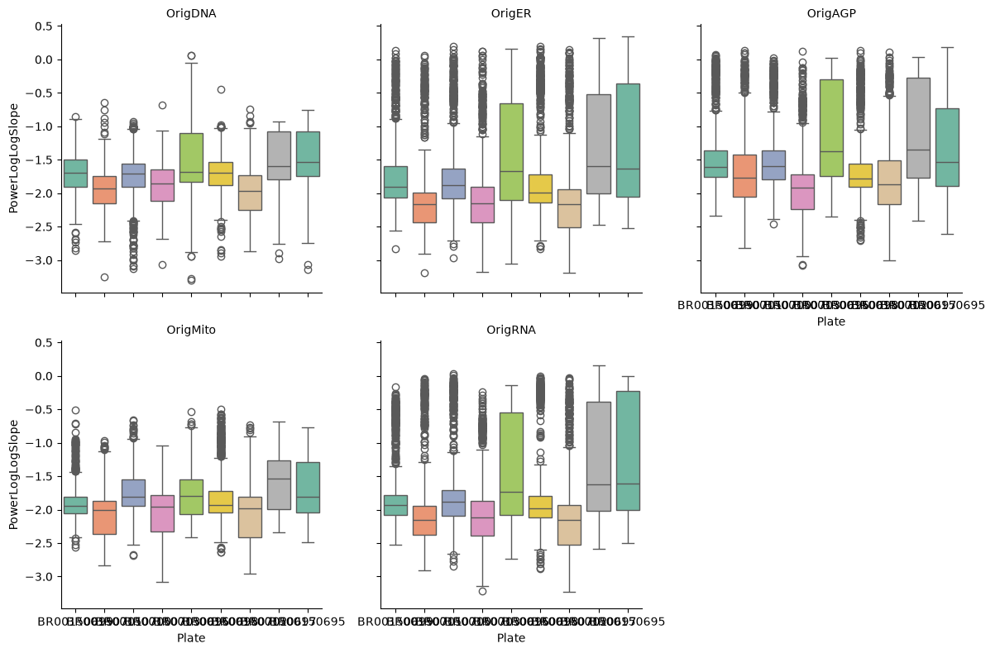

In [4]:
# Plot the distribution of the PowerLogLogSlope metric across all channels and per plate
g = sns.FacetGrid(
    df,
    col="Channel",
    col_wrap=3,  # adjust to your channel count
    height=4,
    sharey=True,
)
g.map_dataframe(
    sns.boxplot,
    x="Metadata_Plate",
    y="ImageQuality_PowerLogLogSlope",
    hue="Metadata_Plate",  # Assign `x` variable to `hue`
    palette="Set2",
    legend=False,  # Disable the legend in the boxplot
)
g.set_axis_labels("Plate", "PowerLogLogSlope")
g.set_titles(col_template="{col_name}")
g.add_legend()
plt.tight_layout()
plt.savefig(figure_dir / "powerloglogslope_distribution.png", dpi=150)
plt.show()


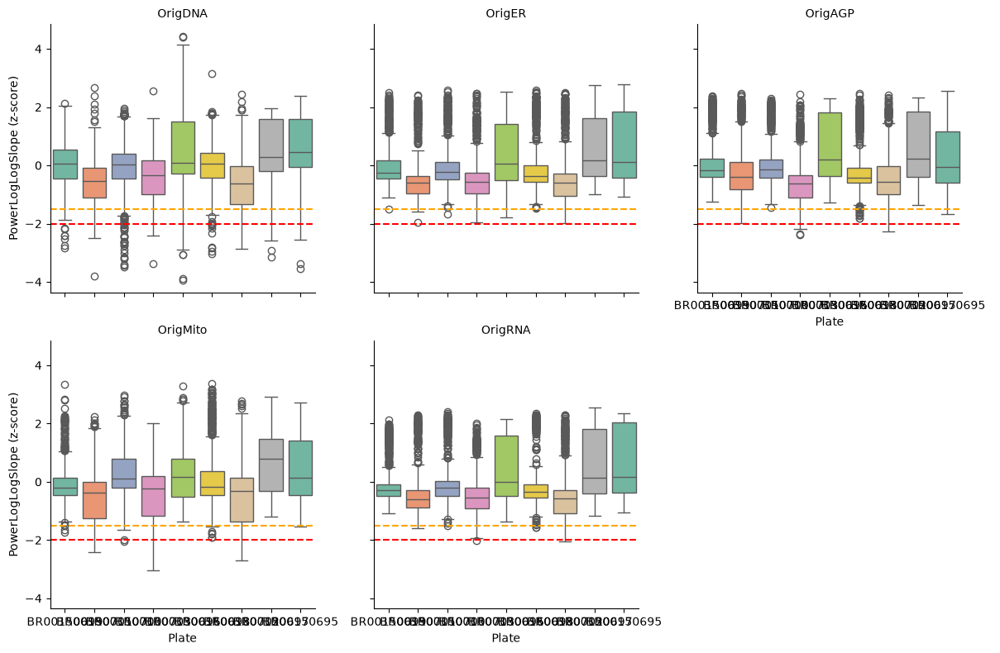

In [5]:
from scipy.stats import zscore

# Compute z-scores per channel
df["PowerLogLogSlope_z"] = df.groupby("Channel")[
    "ImageQuality_PowerLogLogSlope"
].transform(zscore)

# Plot
g = sns.FacetGrid(
    df,
    col="Channel",
    col_wrap=3,
    height=4,
    sharey=True,
)
g.map_dataframe(
    sns.boxplot,
    x="Metadata_Plate",
    y="PowerLogLogSlope_z",
    hue="Metadata_Plate",
    palette="Set2",
    legend=False,
)
# Add red line at z = -2
for ax in g.axes.flatten():
    ax.axhline(-2, color="red", linestyle="--")
# Add red line at z = -1.5
for ax in g.axes.flatten():
    ax.axhline(-1.5, color="orange", linestyle="--")
g.set_axis_labels("Plate", "PowerLogLogSlope (z-score)")
g.set_titles(col_template="{col_name}")
g.add_legend()
plt.tight_layout()
plt.savefig(figure_dir / "powerloglogslope_zscore_distribution.png", dpi=150)
plt.show()


There is no difference in distribution for blur for each channel across plates, so we will run QC thresholds per channel for all plates together.

In [6]:
# Find summary statistics for the PowerLogLogSlope metric across all channels and plates
powerloglog_summary = df.groupby("Channel")["ImageQuality_PowerLogLogSlope"].describe()
print(powerloglog_summary)


           count      mean       std       min       25%       50%       75%  \
Channel                                                                        
OrigAGP   8423.0 -1.500037  0.663330 -3.073201 -1.929874 -1.687156 -1.170348   
OrigDNA   8423.0 -1.716171  0.401955 -3.300240 -1.968159 -1.748034 -1.498021   
OrigER    8423.0 -1.723706  0.744433 -3.193251 -2.184145 -1.985795 -1.514976   
OrigMito  8423.0 -1.861495  0.404407 -3.085516 -2.101264 -1.907275 -1.652649   
OrigRNA   8423.0 -1.724696  0.736418 -3.235061 -2.170236 -1.984579 -1.558257   

               max  
Channel             
OrigAGP   0.187507  
OrigDNA   0.062588  
OrigER    0.343931  
OrigMito -0.502709  
OrigRNA   0.159323  


In [7]:
# metadata columns to include in output data frame
metadata_columns = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site"
]


Number of outliers: 397 (4.71%)
Outliers Range:
ImageQuality_PowerLogLogSlope_OrigDNA Min: -3.3002400954625277
ImageQuality_PowerLogLogSlope_OrigDNA Max: -2.359545599530116


,FileName_OrigDNA,ImageQuality_PowerLogLogSlope_OrigDNA
3578,,-2.360738
5687,,-2.625485
5998,,-2.616663
3100,,-2.396329
3510,,-2.384014

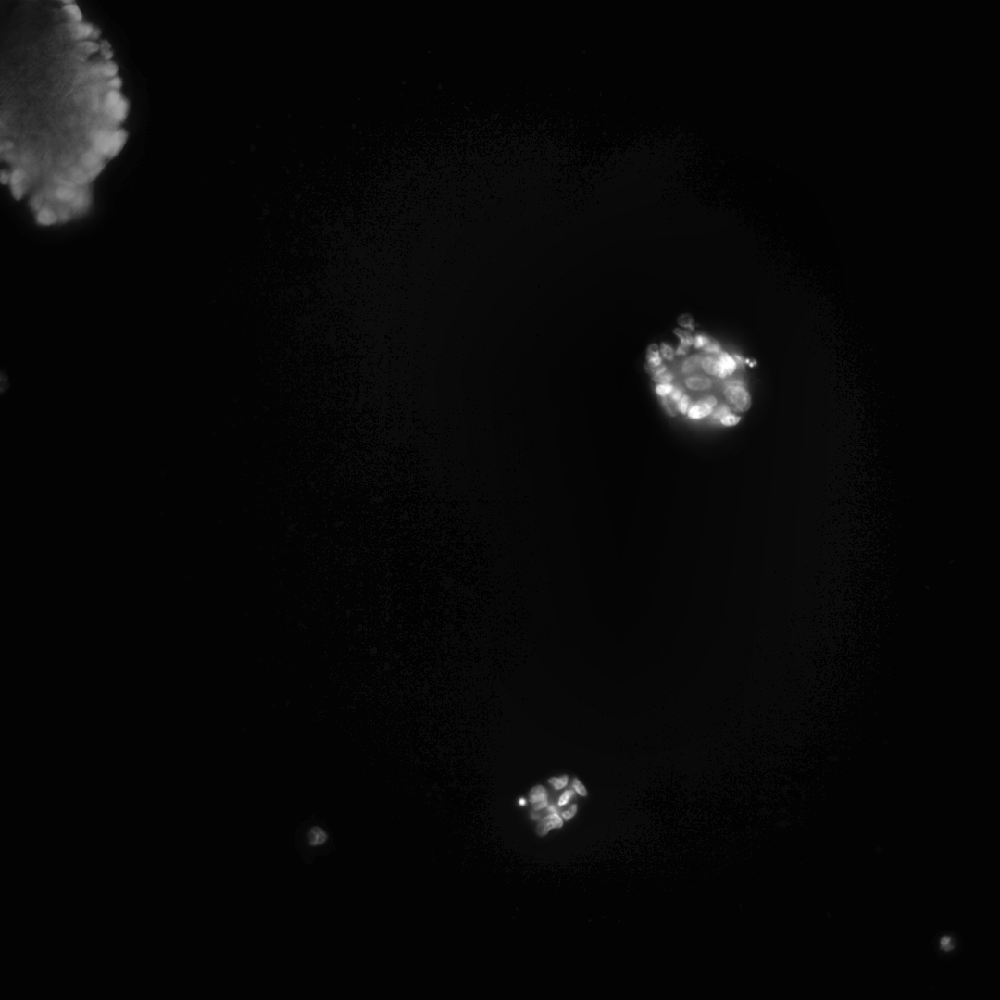
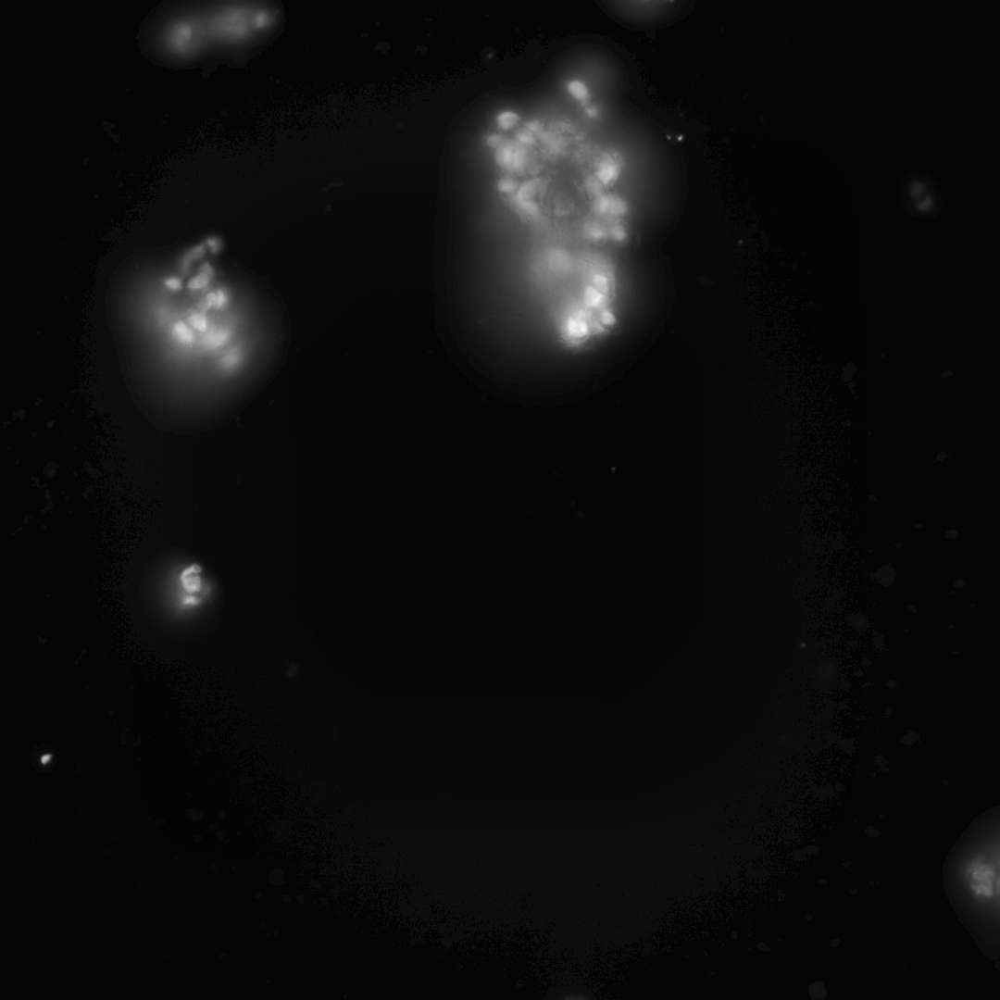
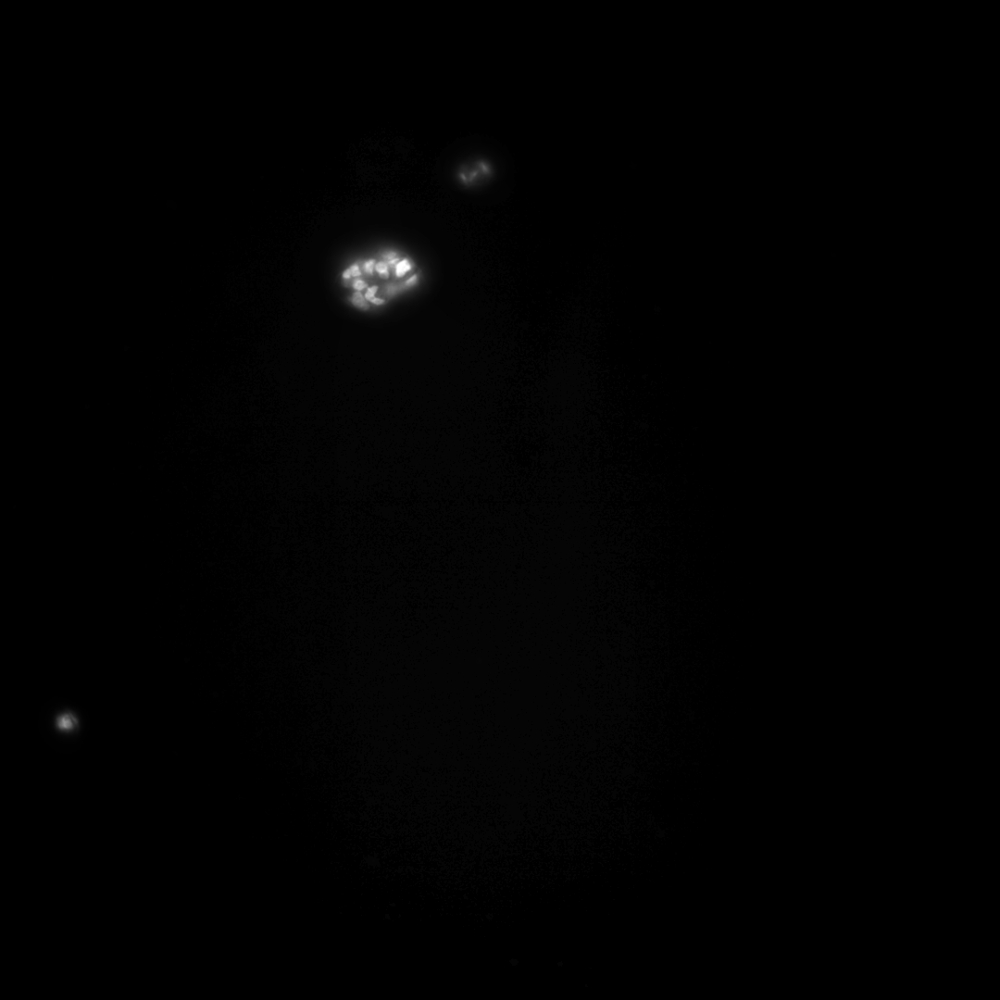
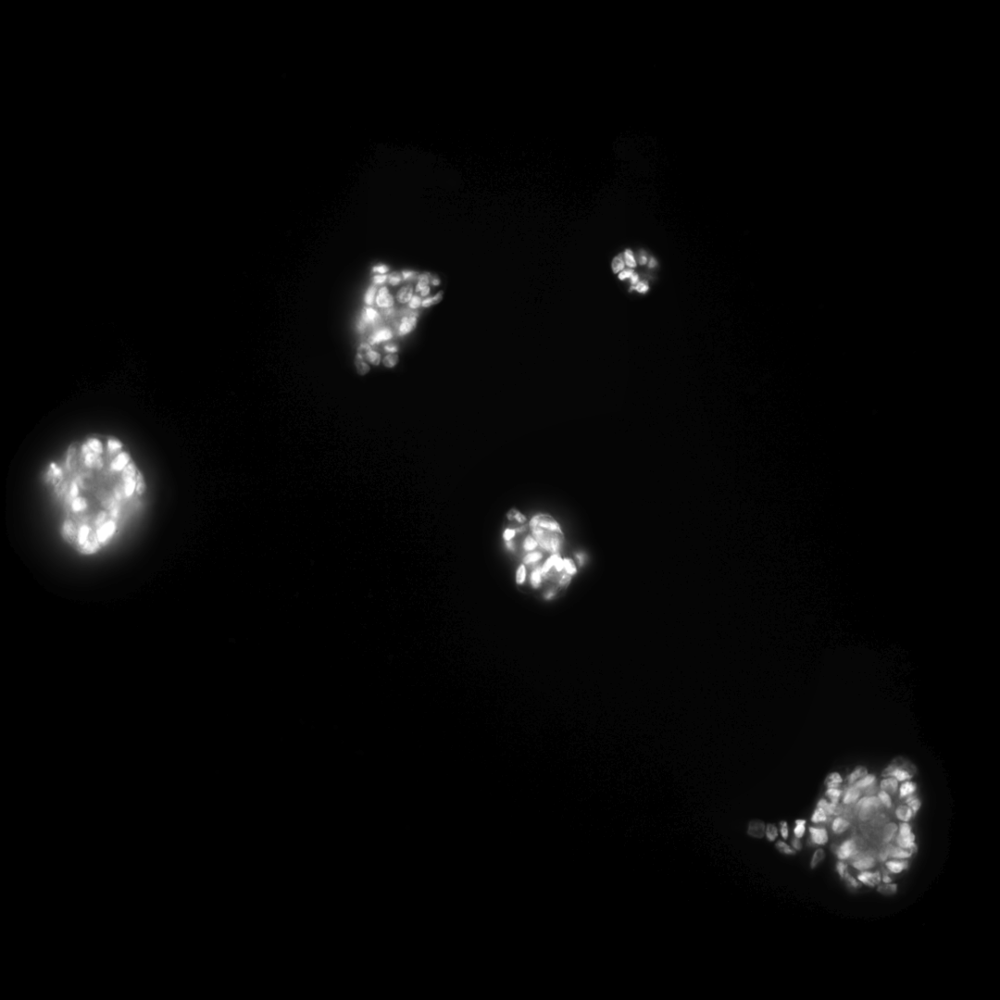
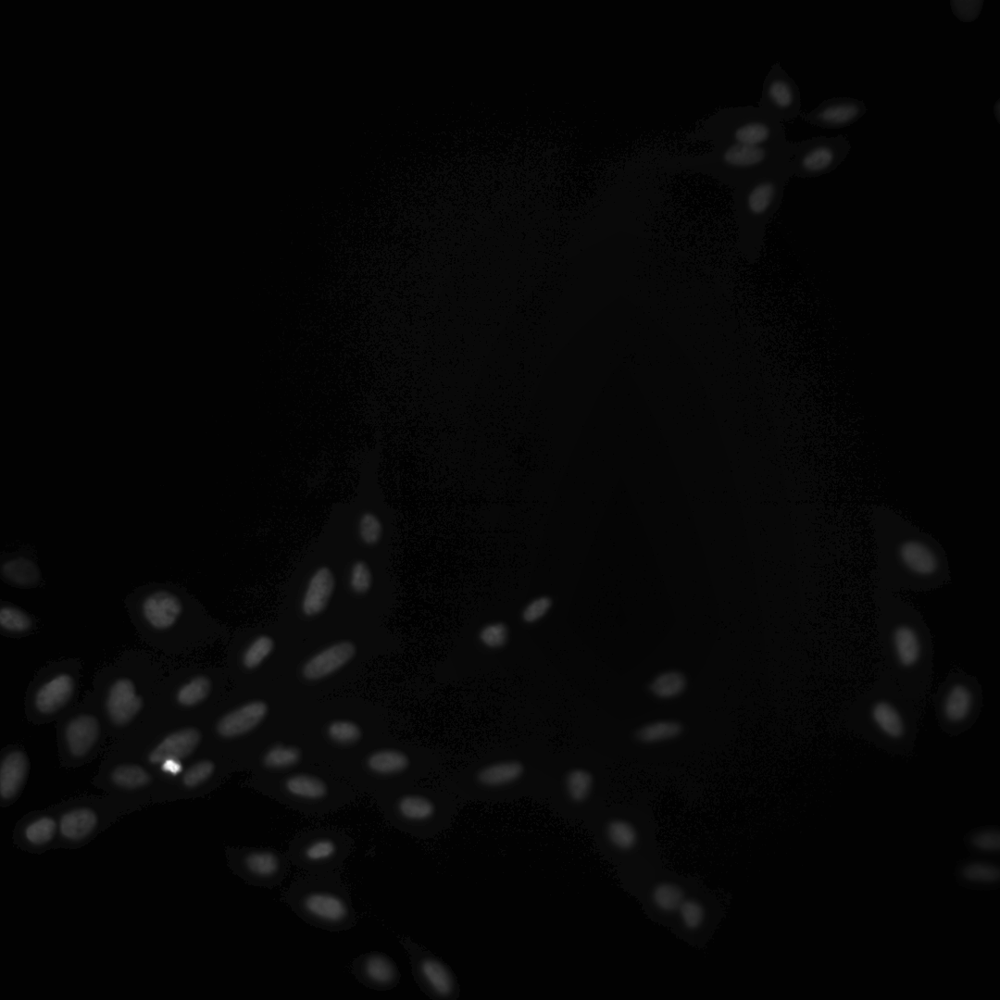

In [8]:
# Find DNA channel blur outliers
blurry_DNA_channel_outliers = find_outliers(
    df=orig_df,
    metadata_columns=metadata_columns + ["FileName_OrigDNA", "PathName_OrigDNA"],
    feature_thresholds={
        "ImageQuality_PowerLogLogSlope_OrigDNA": -1.6,
    },
)

# Convert the outlier data frame into a CytoDataFrame so we can view FOVs
blurry_DNA_outliers_cdf = CytoDataFrame(
    blurry_DNA_channel_outliers,
    display_options={"render_whole_image": True, "brightness": 1},
)

# Display the most blurry FOVs that failed QC.
blurry_DNA_outliers_cdf[
    ["FileName_OrigDNA", "ImageQuality_PowerLogLogSlope_OrigDNA"]
].sort_values("ImageQuality_PowerLogLogSlope_OrigDNA", ascending=False).sample(5)


Number of outliers: 47 (0.56%)
Outliers Range:
ImageQuality_PowerLogLogSlope_OrigER Min: -3.1932505823967303
ImageQuality_PowerLogLogSlope_OrigER Max: -2.845218529747063


,FileName_OrigER,ImageQuality_PowerLogLogSlope_OrigER
3011,,-2.929052
6118,,-2.944280
2860,,-2.859405
3760,,-2.983260
5761,,-2.887487

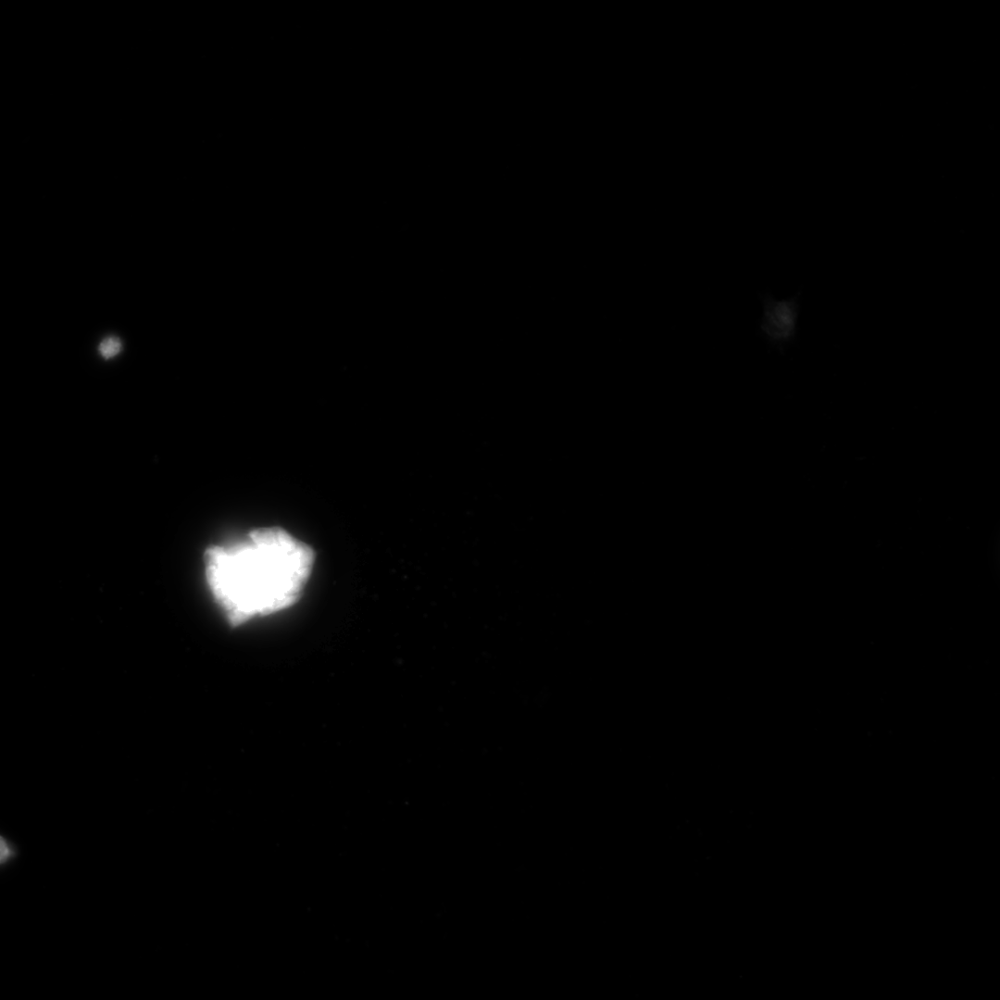
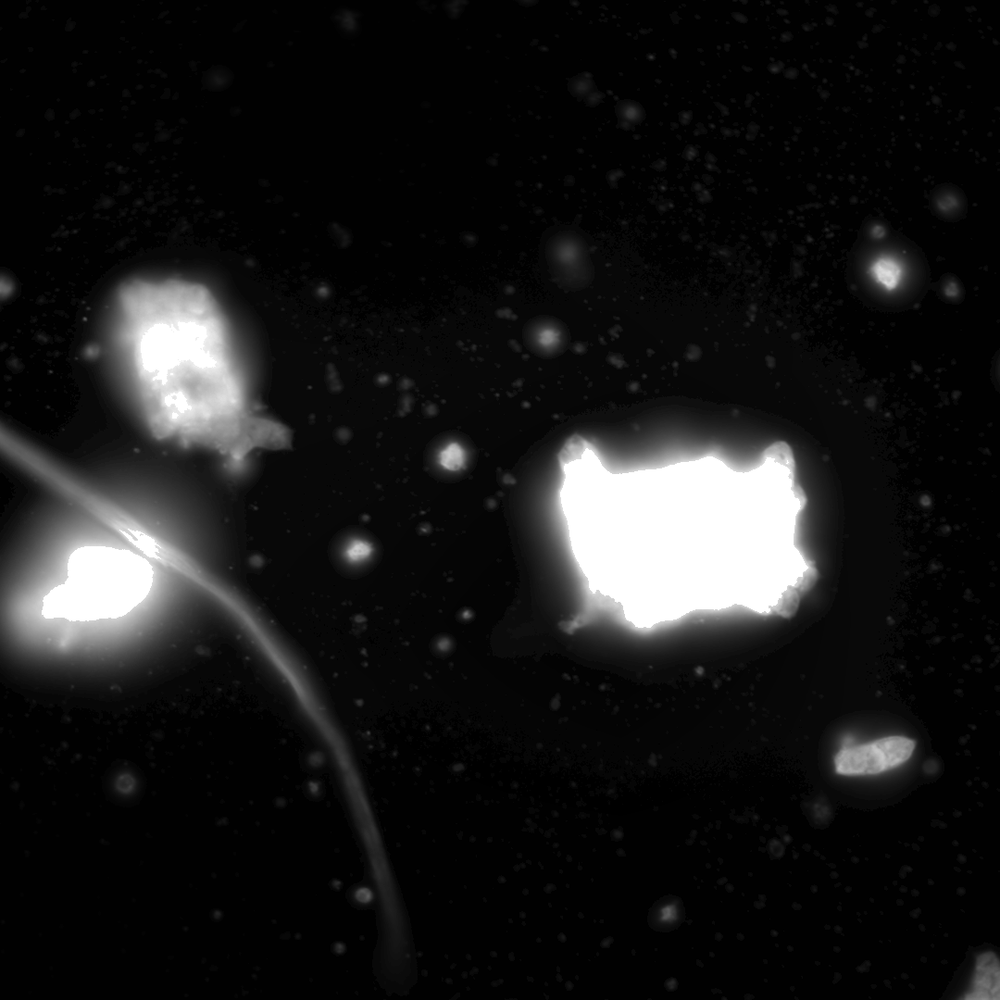
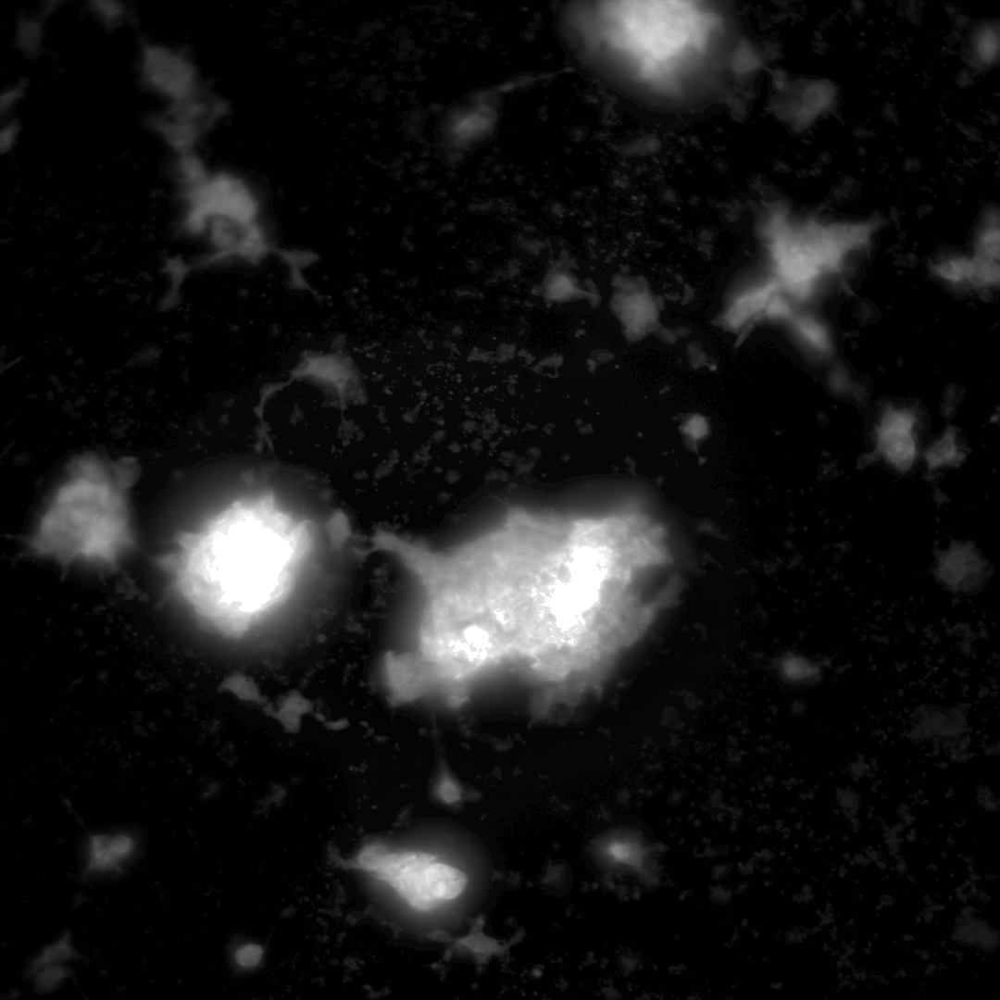
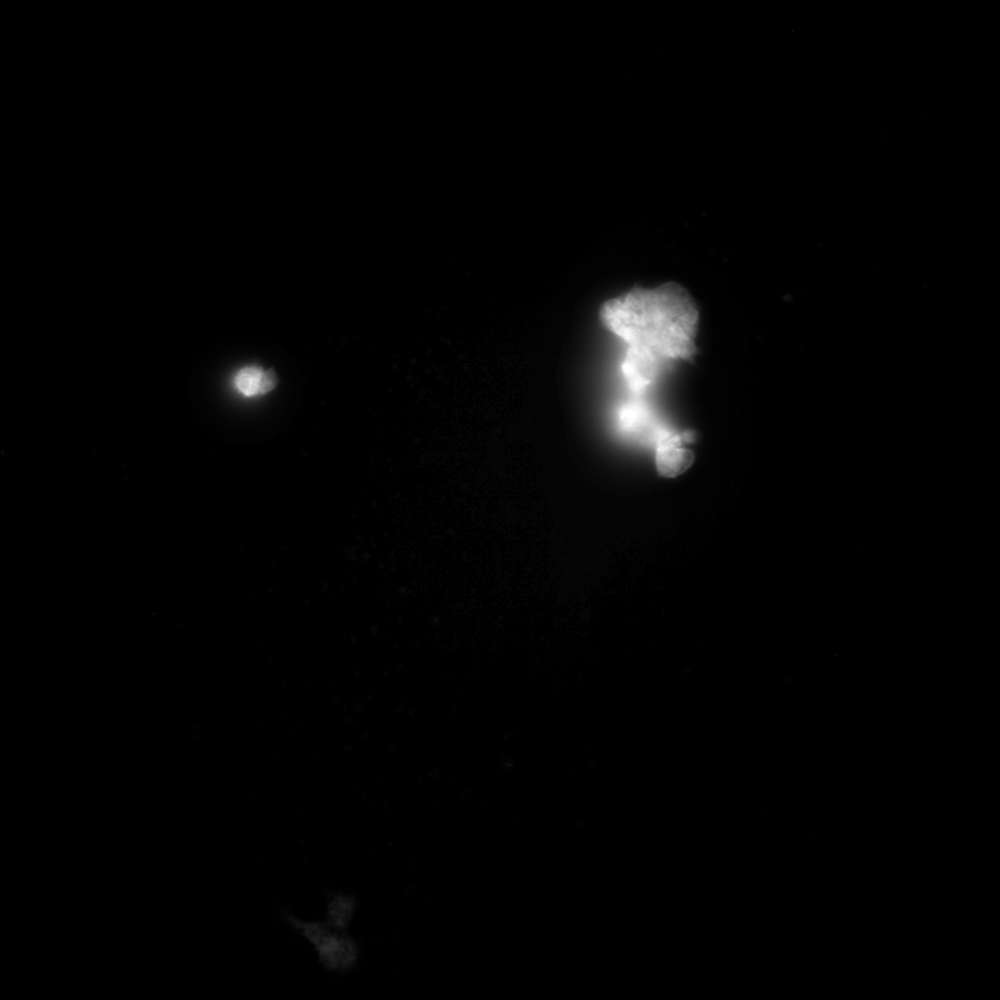
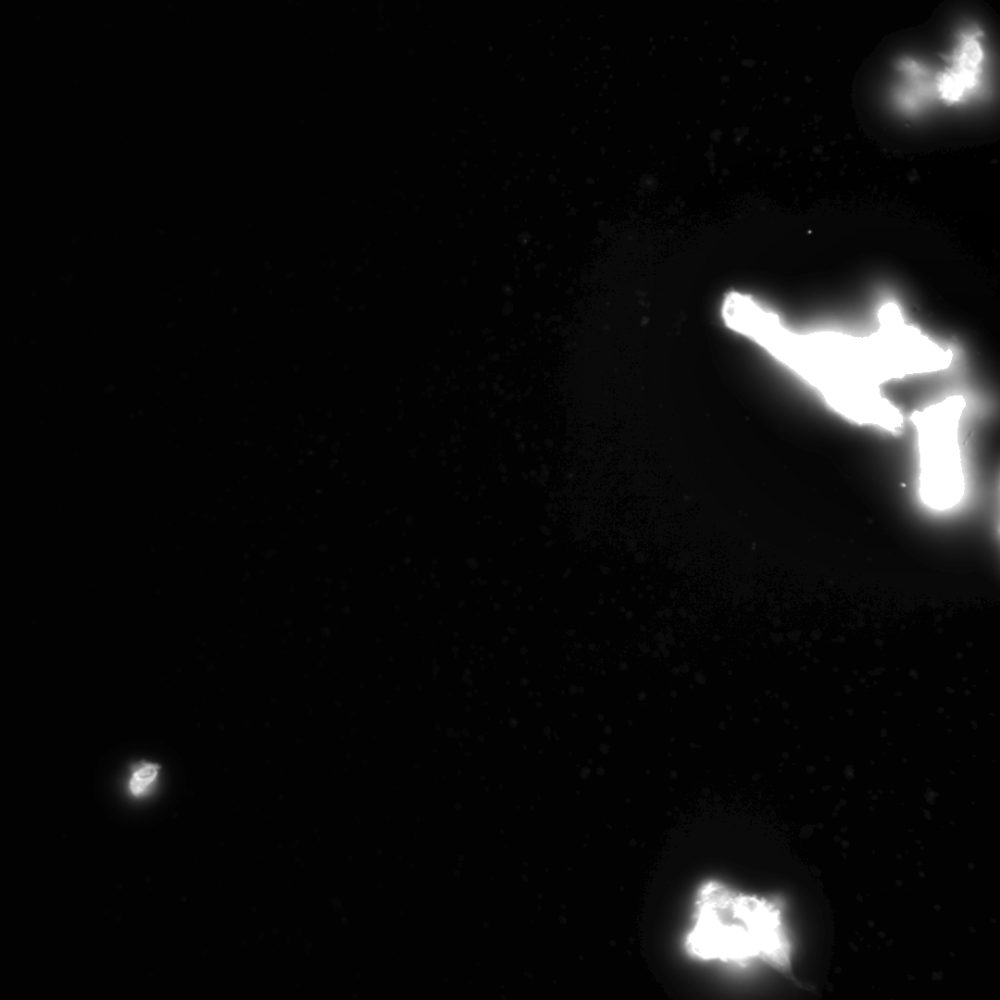

In [9]:
# Find ER channel blur outliers
blurry_ER_channel_outliers = find_outliers(
    df=orig_df,
    metadata_columns=metadata_columns + ["FileName_OrigER", "PathName_OrigER"],
    feature_thresholds={
        "ImageQuality_PowerLogLogSlope_OrigER": -1.5,
    },
)

# Convert the outlier data frame into a CytoDataFrame so we can view FOVs
blurry_ER_outliers_cdf = CytoDataFrame(
    blurry_ER_channel_outliers,
    display_options={"render_whole_image": True, "brightness": 1},
)

# Display the most blurry FOVs that failed QC.
blurry_ER_outliers_cdf[
    ["FileName_OrigER", "ImageQuality_PowerLogLogSlope_OrigER"]
].sort_values("ImageQuality_PowerLogLogSlope_OrigER", ascending=False).sample(5)


Number of outliers: 79 (0.94%)
Outliers Range:
ImageQuality_PowerLogLogSlope_OrigRNA Min: -3.2350611409769425
ImageQuality_PowerLogLogSlope_OrigRNA Max: -2.8295380773899943


,FileName_OrigRNA,ImageQuality_PowerLogLogSlope_OrigRNA
5921,,-3.235061
5910,,-3.189199
3283,,-3.050327
5643,,-2.990046
4775,,-2.874262

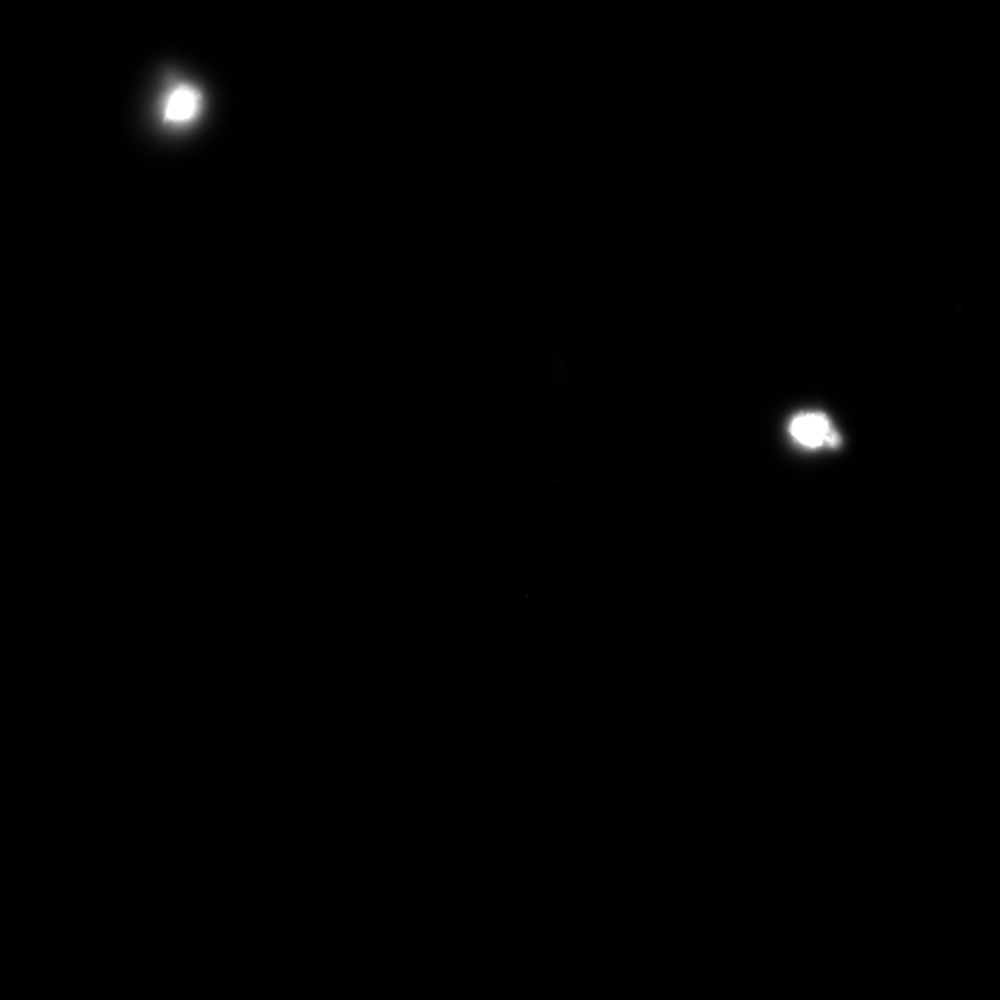
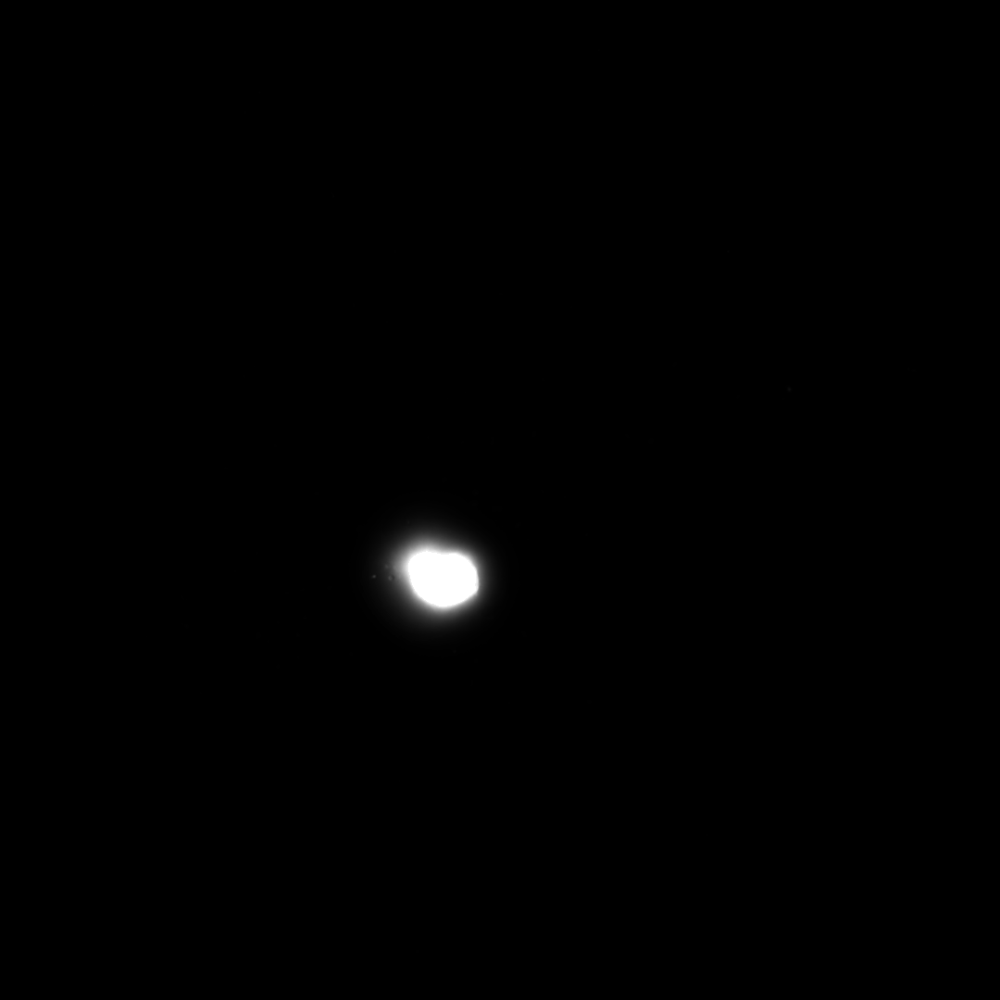
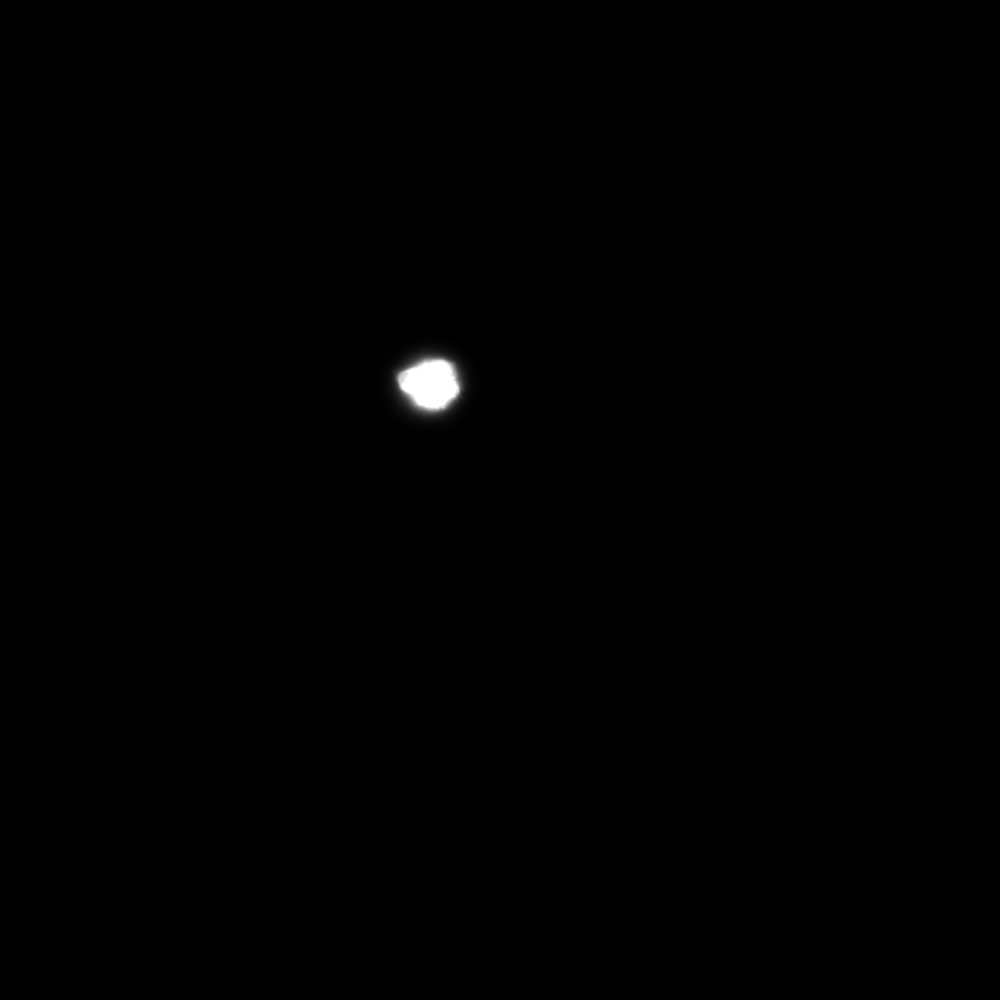
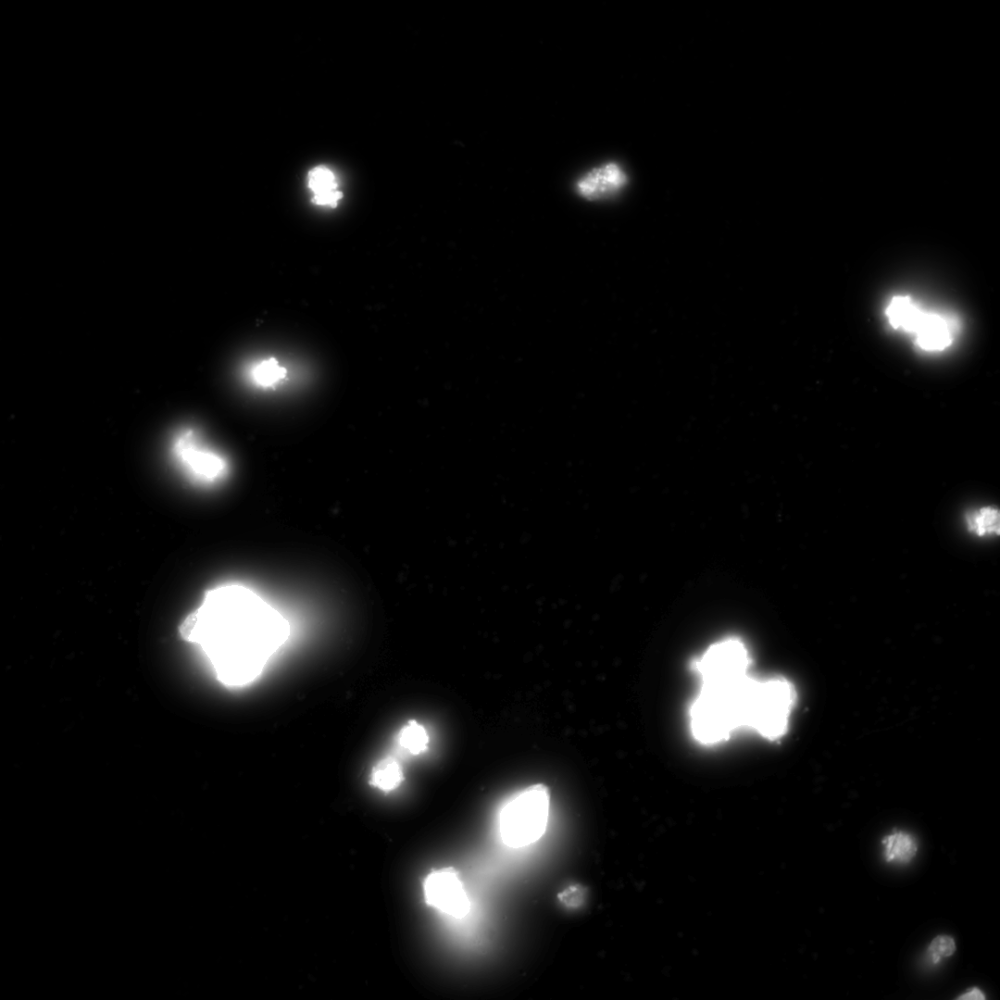
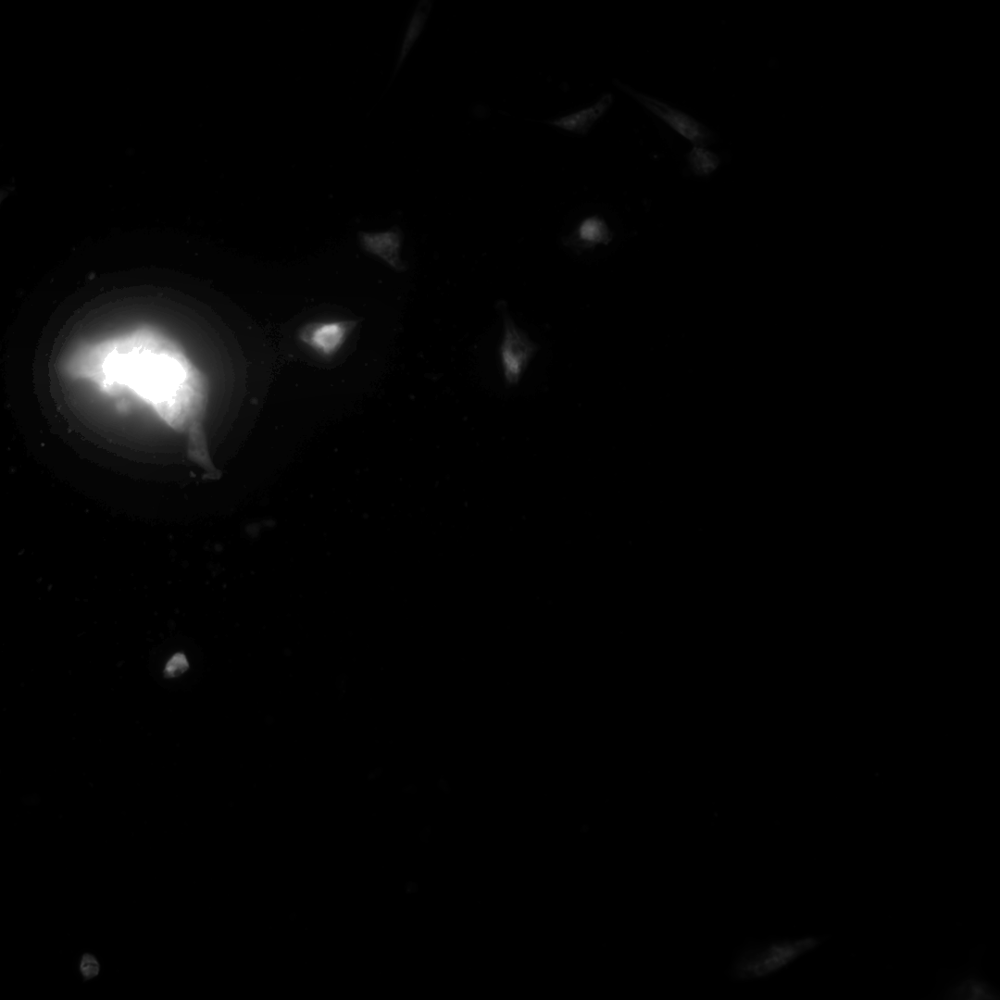

In [10]:
# Find RNA channel blur outliers
blurry_RNA_channel_outliers = find_outliers(
    df=orig_df,
    metadata_columns=metadata_columns + ["FileName_OrigRNA", "PathName_OrigRNA"],
    feature_thresholds={
        "ImageQuality_PowerLogLogSlope_OrigRNA": -1.5,
    },
)

# Convert the outlier data frame into a CytoDataFrame so we can view FOVs
blurry_RNA_outliers_cdf = CytoDataFrame(
    blurry_RNA_channel_outliers,
    display_options={"render_whole_image": True, "brightness": 1},
)

# Display the most blurry FOVs that failed QC.
blurry_RNA_outliers_cdf[
    ["FileName_OrigRNA", "ImageQuality_PowerLogLogSlope_OrigRNA"]
].sort_values("ImageQuality_PowerLogLogSlope_OrigRNA", ascending=False).sample(5)


Number of outliers: 574 (6.81%)
Outliers Range:
ImageQuality_PowerLogLogSlope_OrigMito Min: -3.085515521899903
ImageQuality_PowerLogLogSlope_OrigMito Max: -2.46816114150373


,FileName_OrigMito,ImageQuality_PowerLogLogSlope_OrigMito
5915,,-2.668776
2870,,-2.602234
5793,,-2.488878
1637,,-2.486711
5745,,-2.550574

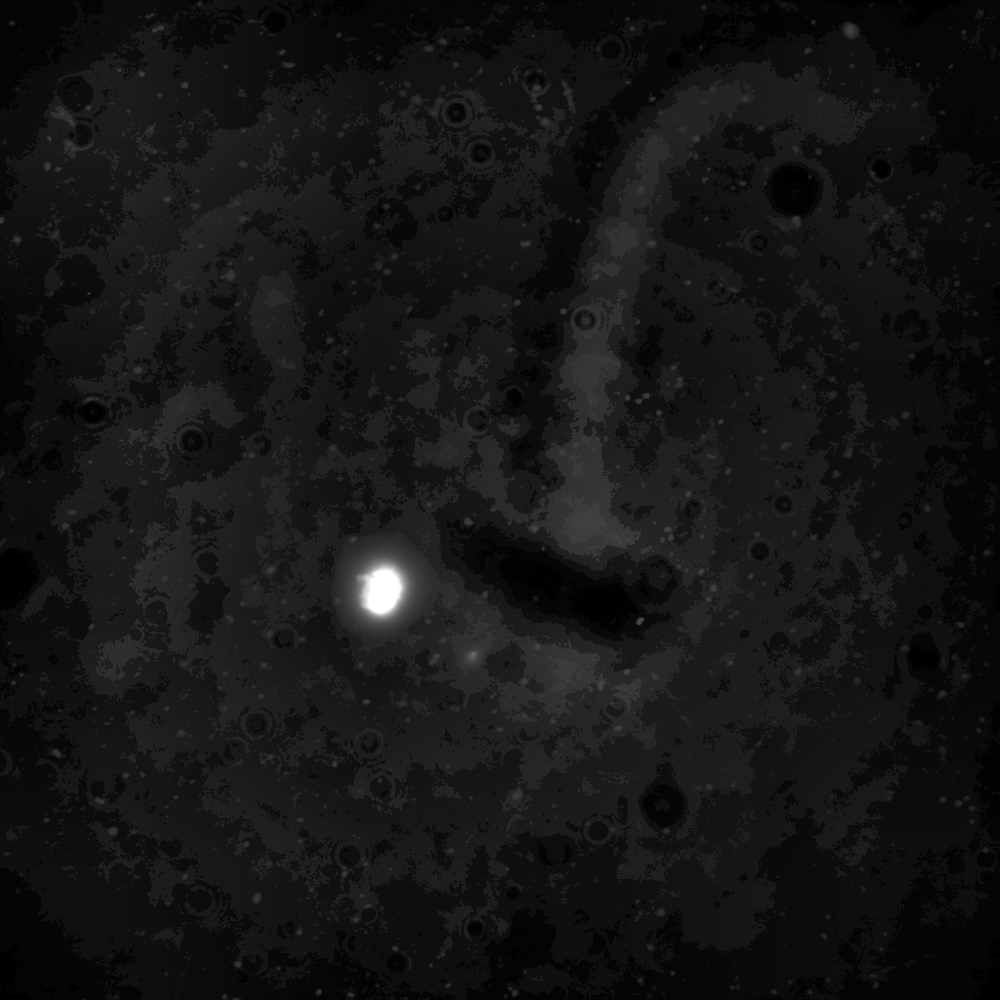
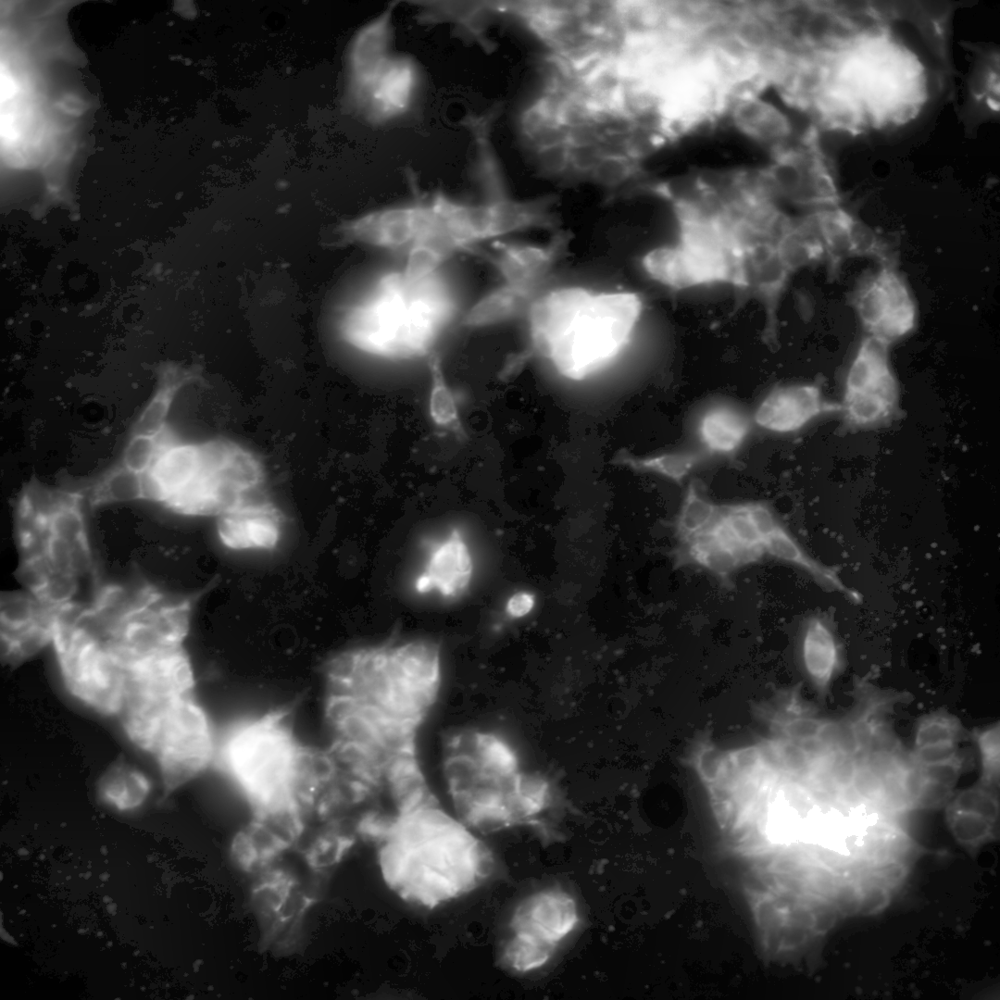
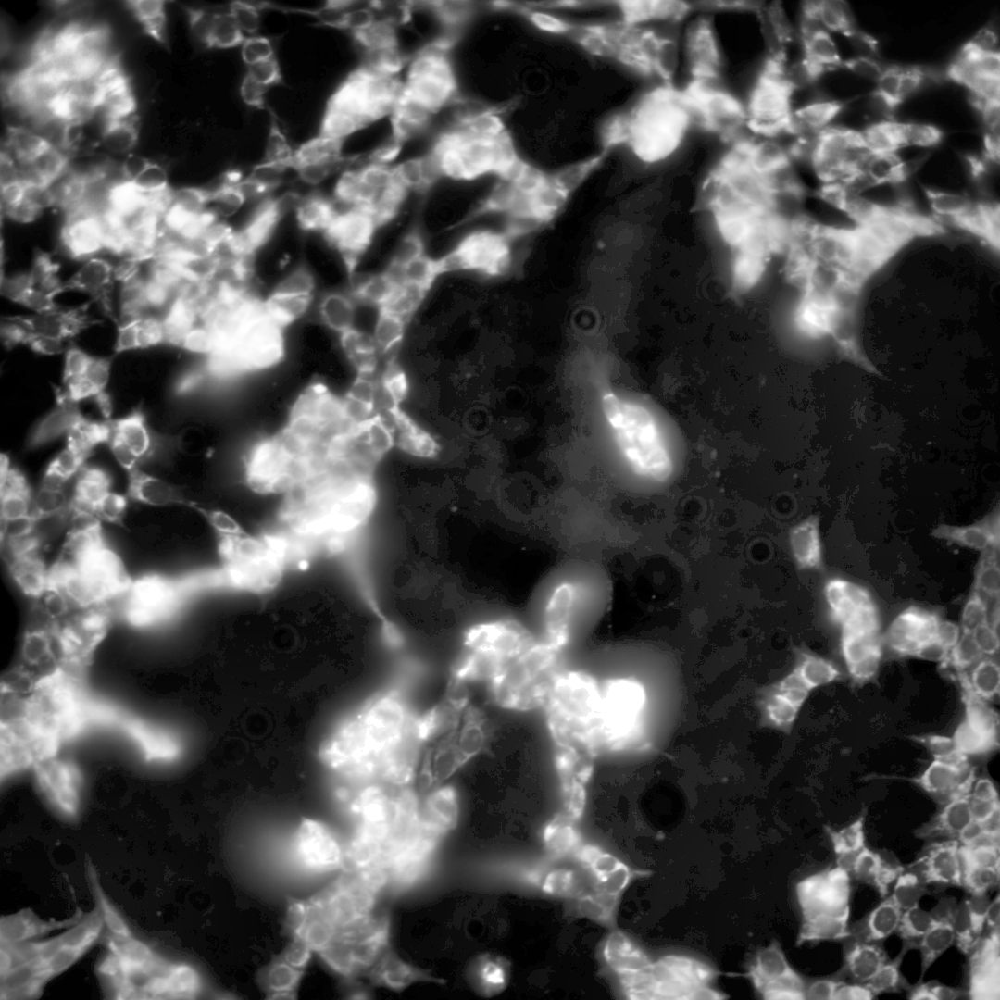
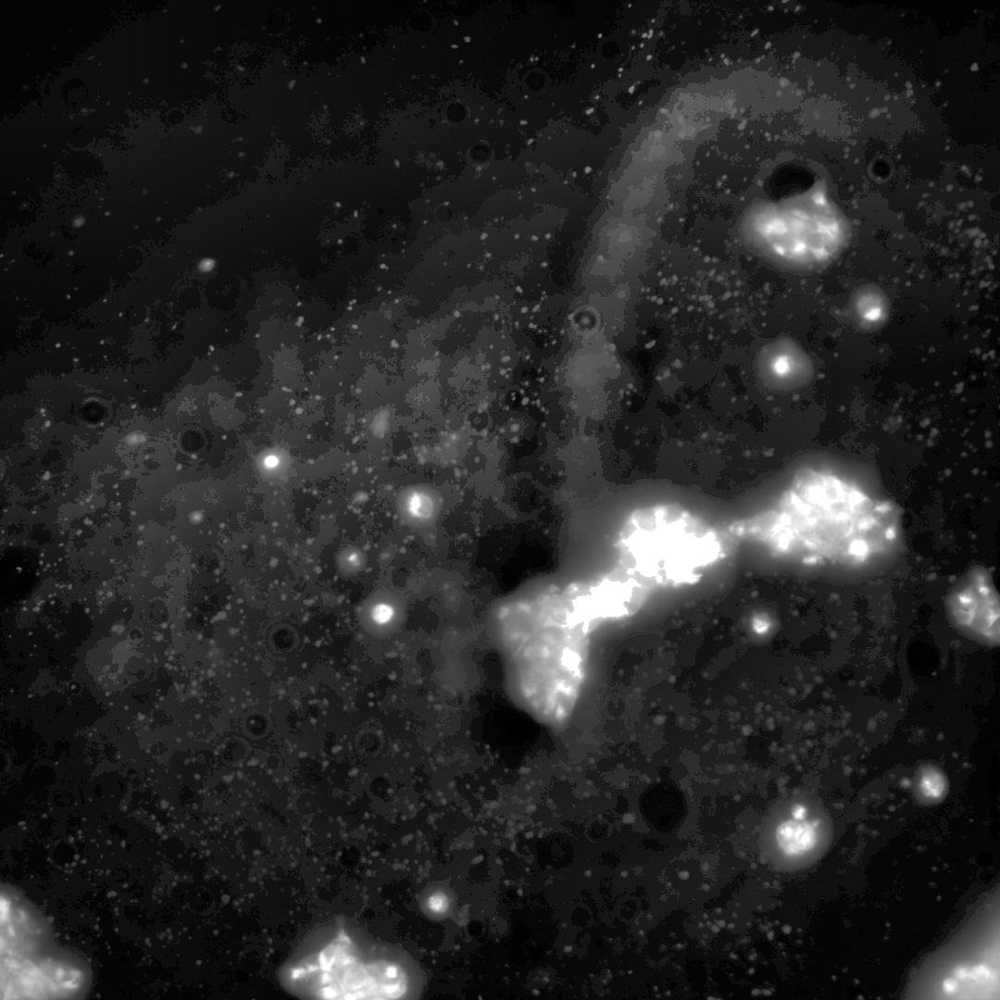
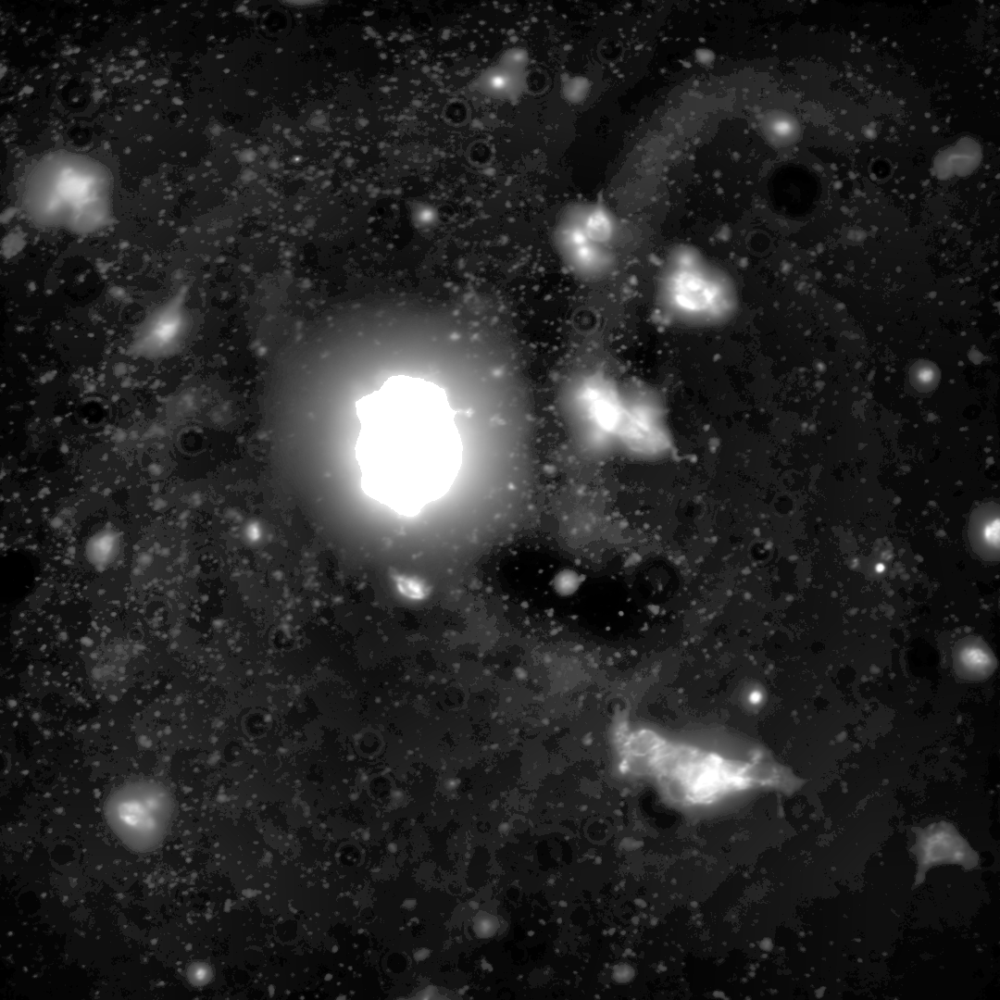

In [11]:
# Find Mito channel blur outliers
blurry_Mito_channel_outliers = find_outliers(
    df=orig_df,
    metadata_columns=metadata_columns + ["FileName_OrigMito", "PathName_OrigMito"],
    feature_thresholds={
        "ImageQuality_PowerLogLogSlope_OrigMito": -1.5,
    },
)

# Convert the outlier data frame into a CytoDataFrame so we can view FOVs
blurry_Mito_outliers_cdf = CytoDataFrame(
    blurry_Mito_channel_outliers,
    display_options={"render_whole_image": True, "brightness": 1},
)

# Display the most blurry FOVs that failed QC.
blurry_Mito_outliers_cdf[
    ["FileName_OrigMito", "ImageQuality_PowerLogLogSlope_OrigMito"]
].sort_values("ImageQuality_PowerLogLogSlope_OrigMito", ascending=False).sample(5)


Number of outliers: 251 (2.98%)
Outliers Range:
ImageQuality_PowerLogLogSlope_OrigAGP Min: -3.073200563730412
ImageQuality_PowerLogLogSlope_OrigAGP Max: -2.4961077341417783


,FileName_OrigAGP,ImageQuality_PowerLogLogSlope_OrigAGP
5843,,-2.536841
3007,,-2.574224
3030,,-2.623508
3105,,-2.872614
1186,,-2.509564

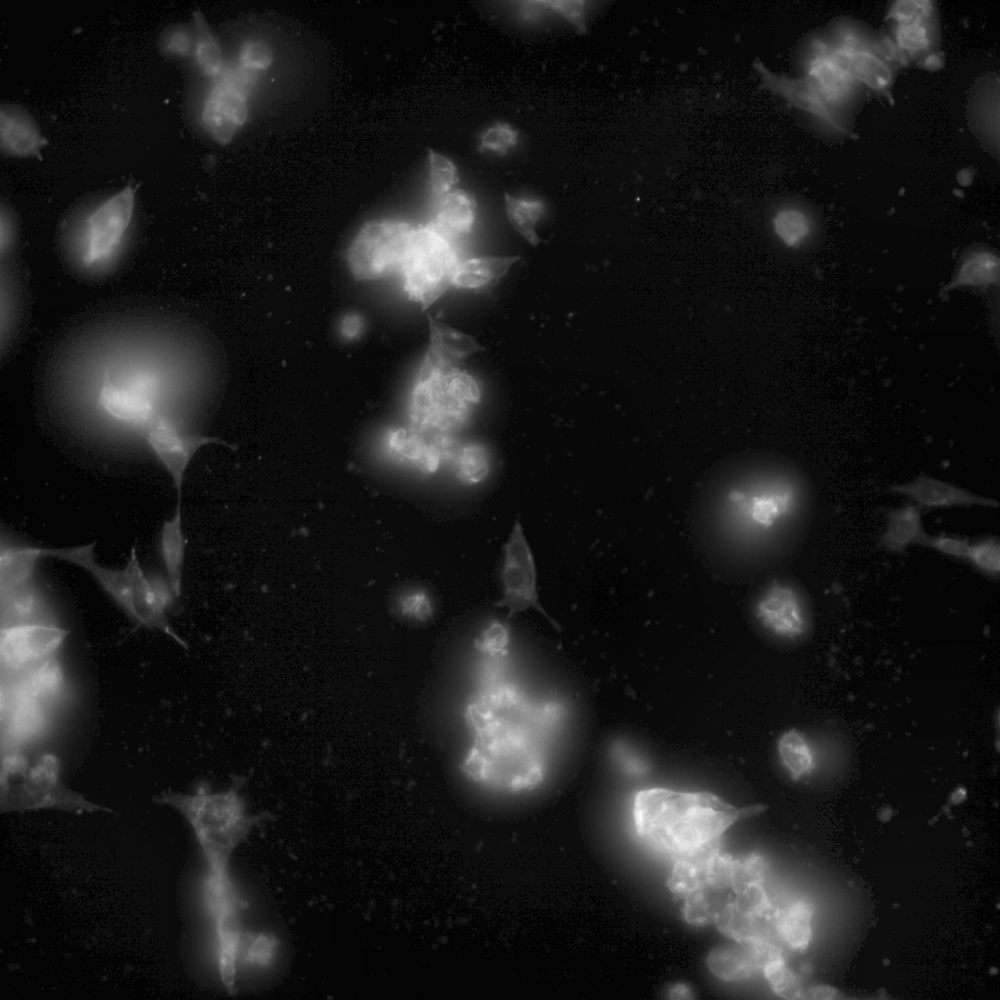
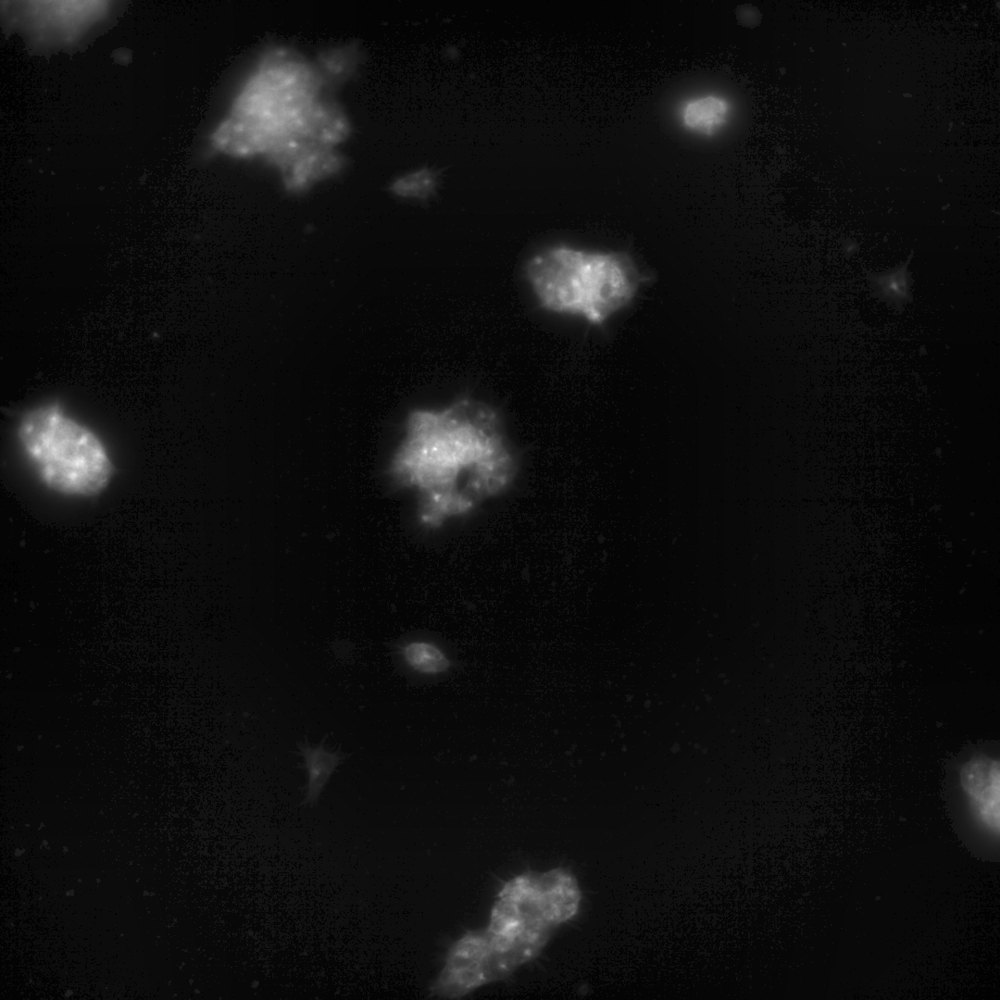
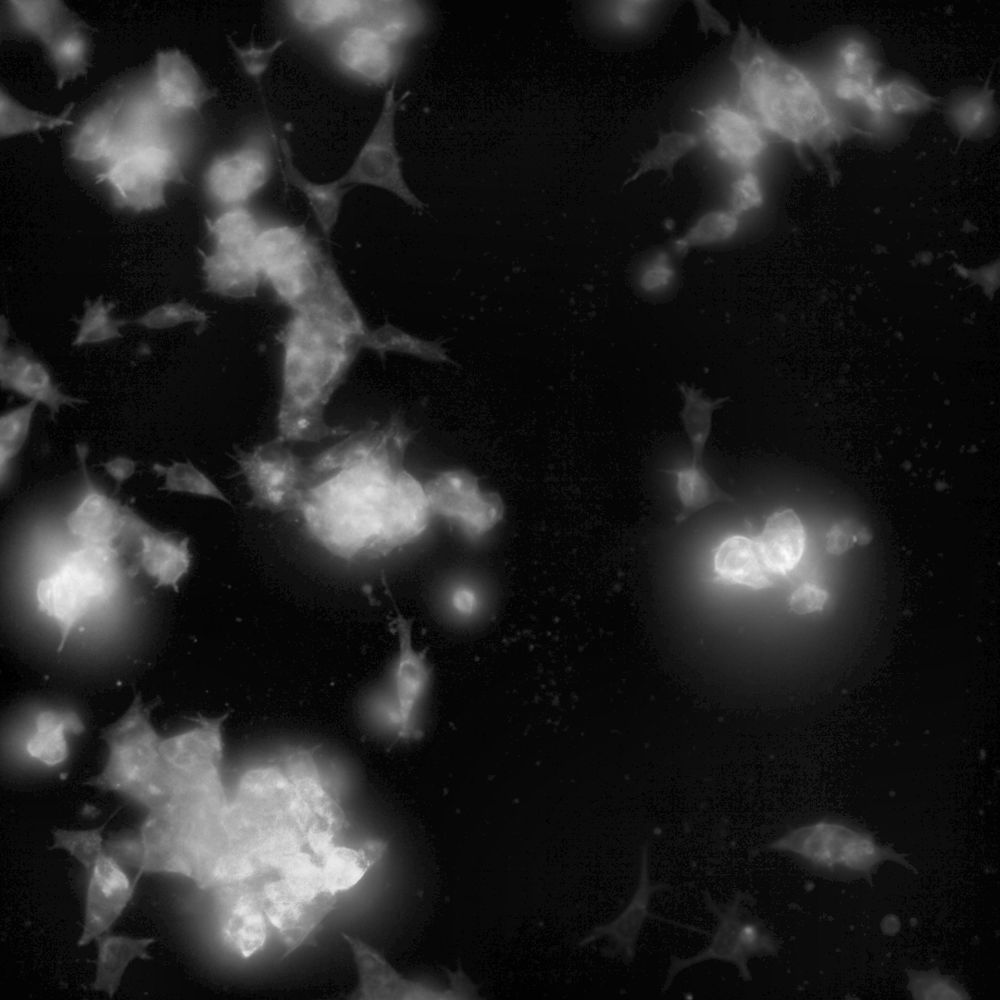
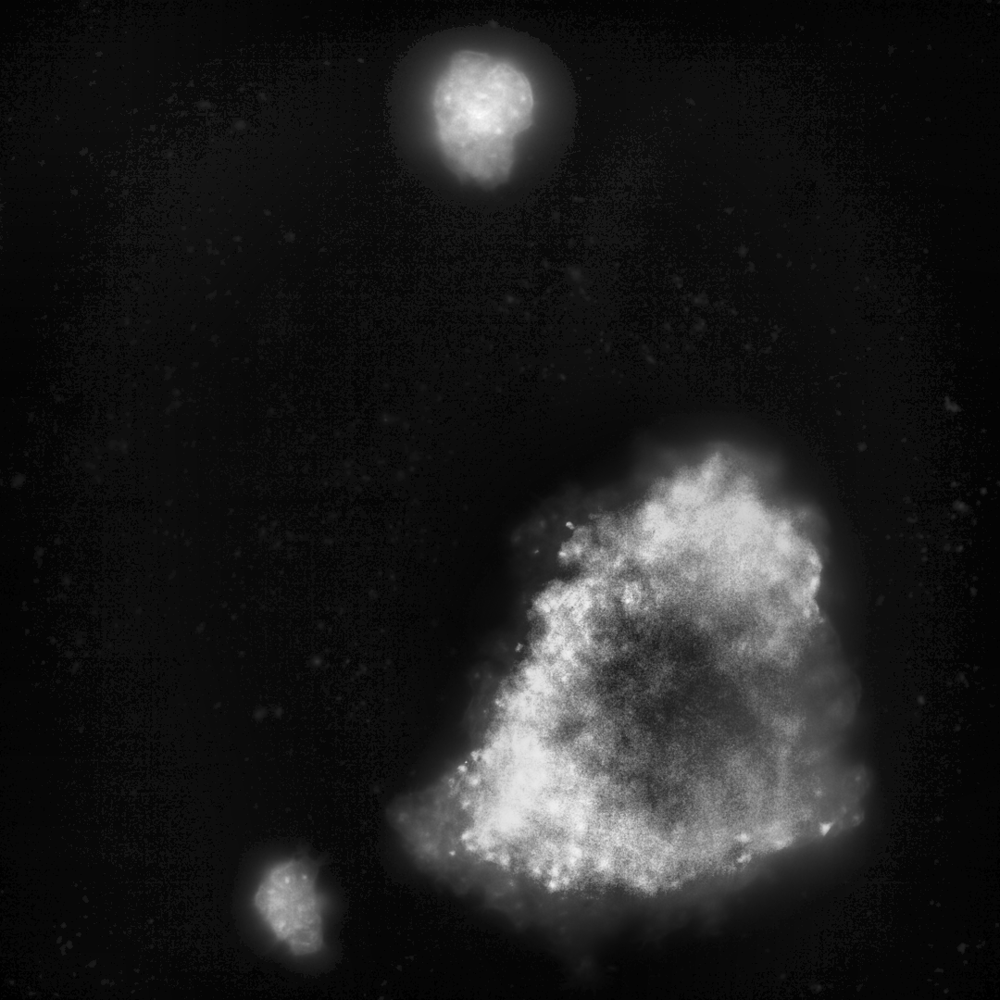
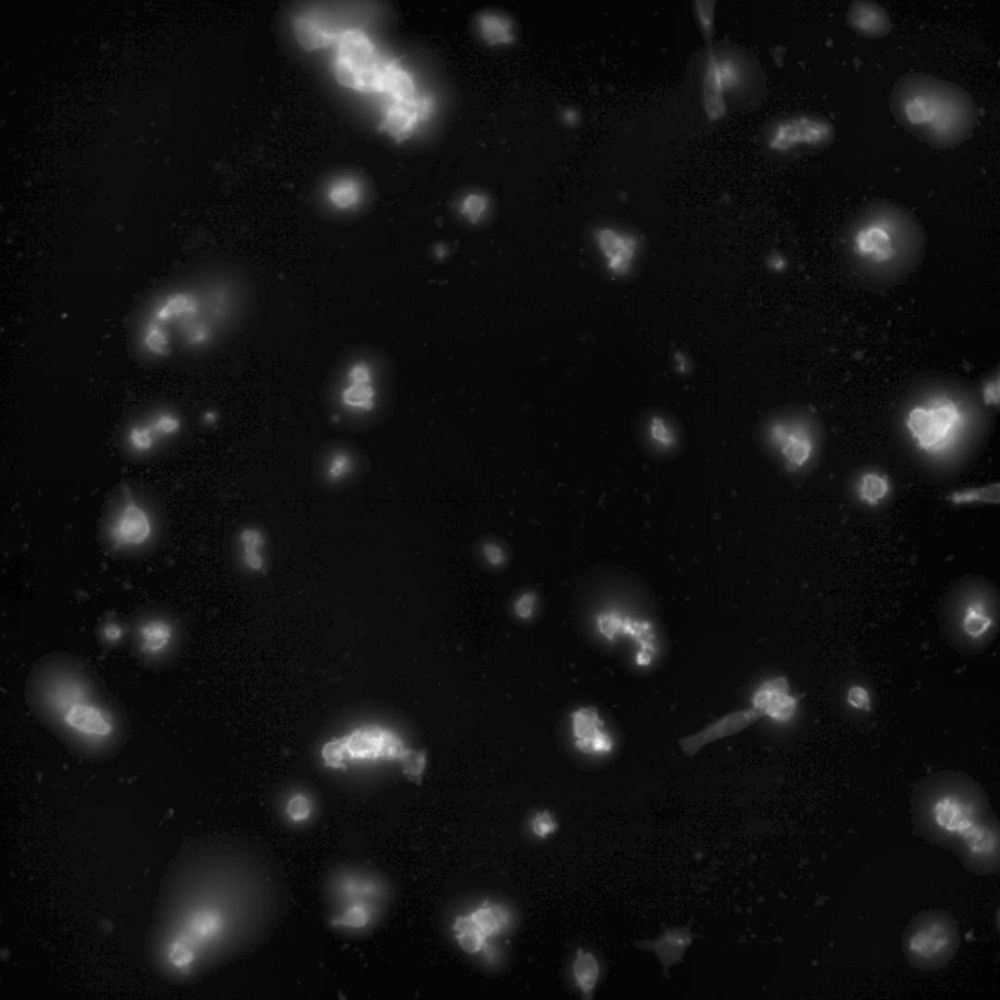

In [12]:
# Find AGP channel blur outliers
blurry_AGP_channel_outliers = find_outliers(
    df=orig_df,
    metadata_columns=metadata_columns + ["FileName_OrigAGP", "PathName_OrigAGP"],
    feature_thresholds={
        "ImageQuality_PowerLogLogSlope_OrigAGP": -1.5,
    },
)

# Convert the outlier data frame into a CytoDataFrame so we can view FOVs
blurry_AGP_outliers_cdf = CytoDataFrame(
    blurry_AGP_channel_outliers,
    display_options={"render_whole_image": True, "brightness": 1},
)

# Display the most blurry FOVs that failed QC.
blurry_AGP_outliers_cdf[
    ["FileName_OrigAGP", "ImageQuality_PowerLogLogSlope_OrigAGP"]
].sort_values("ImageQuality_PowerLogLogSlope_OrigAGP", ascending=False).sample(5)


### Identify threshold values to use to find outliers above and below the mean

**Note:** These values will be used in CellProfiler to flag and not process images.

In [13]:
# Initialize a dictionary to store thresholds
raw_thresholds = {}

# List of channels and their corresponding outlier dataframes
channel_outliers = {
    "OrigDNA": blurry_DNA_channel_outliers,
    "OrigER": blurry_ER_channel_outliers,
    "OrigRNA": blurry_RNA_channel_outliers,
    "OrigMito": blurry_Mito_channel_outliers,
    "OrigAGP": blurry_AGP_channel_outliers,
}

# Iterate through each channel and calculate the threshold
for channel, outliers_df in channel_outliers.items():
    column_name = f"ImageQuality_PowerLogLogSlope_{channel}"
    if column_name in outliers_df.columns and not outliers_df.empty:
        # Take the max as the threshold for that channel
        threshold_value = outliers_df[column_name].max()
        raw_thresholds[channel] = threshold_value
    else:
        raw_thresholds[channel] = None  # or np.nan if you prefer

# Save the thresholds for blur for each channel to file to update cppipe later
with open("blur_thresholds.txt", "w") as f:
    for channel, threshold in raw_thresholds.items():
        f.write(f"{channel}: {threshold}\n")

# Print the thresholds in a vertical format
for channel, threshold in raw_thresholds.items():
    print(f"Channel: {channel}, Threshold: {threshold}")


Channel: OrigDNA, Threshold: -2.359545599530116
Channel: OrigER, Threshold: -2.845218529747063
Channel: OrigRNA, Threshold: -2.8295380773899943
Channel: OrigMito, Threshold: -2.46816114150373
Channel: OrigAGP, Threshold: -2.4961077341417783


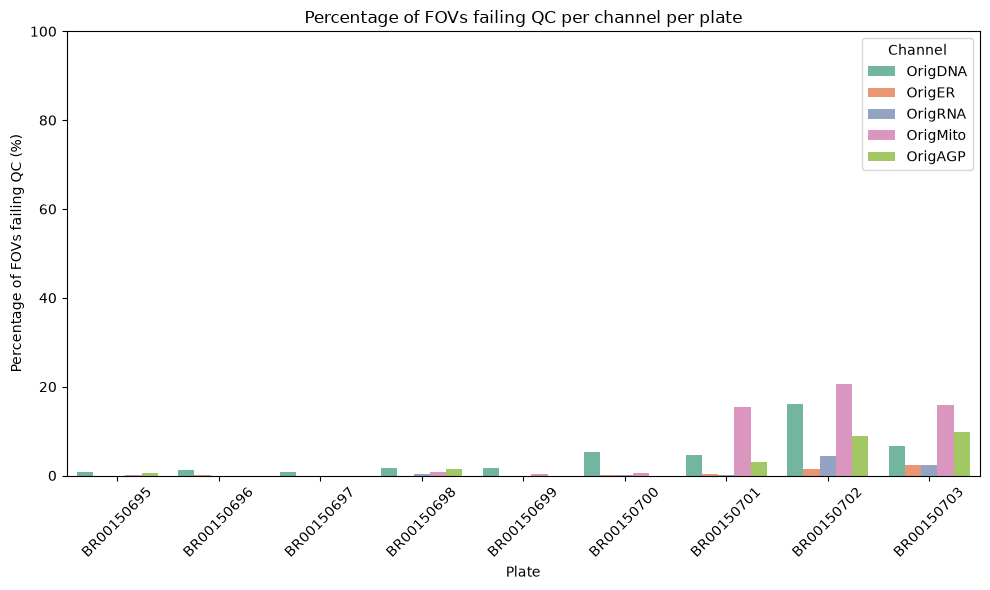

In [14]:
# List of channels
channels = ["OrigDNA", "OrigER", "OrigRNA", "OrigMito", "OrigAGP"]

# Make list of PowerLogLogSlope columns corresponding to blur thresholds
powerlog_cols = [f"ImageQuality_PowerLogLogSlope_{ch}" for ch in channels]

# Compute percentage of FOVs failing QC per channel per plate using blur thresholds
fail_summary = []

for plate, plate_df in orig_df.groupby("Metadata_Plate"):
    total_fovs = len(plate_df)
    for ch, col in zip(channels, powerlog_cols):
        threshold = raw_thresholds.get(ch)
        if threshold is not None:
            # FOV fails if below the blur threshold
            num_fail = (plate_df[col] < threshold).sum()
            pct_fail = num_fail / total_fovs * 100
            fail_summary.append(
                {"Metadata_Plate": plate, "Channel": ch, "PctFail": pct_fail}
            )

fail_df = pd.DataFrame(fail_summary)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=fail_df, x="Metadata_Plate", y="PctFail", hue="Channel", palette="Set2"
)
plt.ylabel("Percentage of FOVs failing QC (%)")
plt.xlabel("Plate")
plt.ylim(0, 100)
plt.title("Percentage of FOVs failing QC per channel per plate")
plt.legend(title="Channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Saturation metric

For saturation metrics, we are looking for:

- Smudged images or images containing large artifacts
- Overly saturated channels which can occur in any channel

This means that we will be setting a threshold for outliers for all channels as the metric PercentMaximal is a range from 0 - 100. We expect if images have 1% of all pixels at the max value to be over-saturated.

In [15]:
summary_statistics = df["ImageQuality_PercentMaximal"].describe()
print(summary_statistics)


count    42115.000000
mean         0.178500
std          1.506384
min          0.000086
25%          0.000086
50%          0.000086
75%          0.004372
max         87.075189
Name: ImageQuality_PercentMaximal, dtype: float64


In [16]:
# List of channels to check
channels = ["OrigDNA", "OrigER", "OrigRNA", "OrigMito", "OrigAGP"]

# Make sure PercentMaximal columns are numeric
for channel in channels:
    col = f"ImageQuality_PercentMaximal_{channel}"
    if col in orig_df.columns:
        orig_df[col] = pd.to_numeric(orig_df[col], errors="coerce")

# Columns to keep
percentmax_cols = [f"ImageQuality_PercentMaximal_{ch}" for ch in channels]
keep_cols = ["Metadata_Plate", "Metadata_Well"] + percentmax_cols
file_path_cols = [
    c for c in orig_df.columns if c.startswith(("FileName_", "PathName_"))
]
keep_cols += file_path_cols

# Select only the rows that fail (>=1) in any PercentMaximal column
df_fails_trimmed = orig_df.loc[
    (orig_df[percentmax_cols] >= 1).any(axis=1), keep_cols
].copy()

# Print shape and percentage of FOVs failing
pct_failing = len(df_fails_trimmed) / len(orig_df) * 100
print(
    f"Total FOVs failing ≥1% in any channel: {len(df_fails_trimmed)} ({pct_failing:.2f}%)"
)

df_fails_trimmed.head()


Total FOVs failing ≥1% in any channel: 970 (11.52%)


,Metadata_Plate,Metadata_Well,ImageQuality_PercentMaximal_OrigDNA,ImageQuality_PercentMaximal_OrigER,ImageQuality_PercentMaximal_OrigRNA,ImageQuality_PercentMaximal_OrigMito,ImageQuality_PercentMaximal_OrigAGP,FileName_OrigAGP,FileName_OrigDNA,FileName_OrigER,FileName_OrigMito,FileName_OrigRNA,PathName_OrigAGP,PathName_OrigDNA,PathName_OrigER,PathName_OrigMito,PathName_OrigRNA
19,BR00150699,C05,0.000086,0.000086,0.027263,15.220850,0.000086,r03c05f02p01-ch3sk1fk1fl1.tiff,r03c05f02p01-ch5sk1fk1fl1.tiff,r03c05f02p01-ch2sk1fk1fl1.tiff,r03c05f02p01-ch4sk1fk1fl1.tiff,r03c05f02p01-ch6sk1fk1fl1.tiff,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...
20,BR00150699,C05,0.000086,0.000086,0.000086,5.662980,0.000086,r03c05f03p01-ch3sk1fk1fl1.tiff,r03c05f03p01-ch5sk1fk1fl1.tiff,r03c05f03p01-ch2sk1fk1fl1.tiff,r03c05f03p01-ch4sk1fk1fl1.tiff,r03c05f03p01-ch6sk1fk1fl1.tiff,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...
21,BR00150699,C05,0.000086,0.000086,0.000086,20.314386,0.000086,r03c05f04p01-ch3sk1fk1fl1.tiff,r03c05f04p01-ch5sk1fk1fl1.tiff,r03c05f04p01-ch2sk1fk1fl1.tiff,r03c05f04p01-ch4sk1fk1fl1.tiff,r03c05f04p01-ch6sk1fk1fl1.tiff,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...
22,BR00150699,C05,0.000086,0.000086,0.000086,27.241512,0.000086,r03c05f05p01-ch3sk1fk1fl1.tiff,r03c05f05p01-ch5sk1fk1fl1.tiff,r03c05f05p01-ch2sk1fk1fl1.tiff,r03c05f05p01-ch4sk1fk1fl1.tiff,r03c05f05p01-ch6sk1fk1fl1.tiff,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...
25,BR00150699,C05,0.000086,0.000086,0.000086,16.013546,0.000086,r03c05f08p01-ch3sk1fk1fl1.tiff,r03c05f08p01-ch5sk1fk1fl1.tiff,r03c05f08p01-ch2sk1fk1fl1.tiff,r03c05f08p01-ch4sk1fk1fl1.tiff,r03c05f08p01-ch6sk1fk1fl1.tiff,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...,/home/jenna/mnt/bandicoot/PCCMA_data/Atlas_v2_...


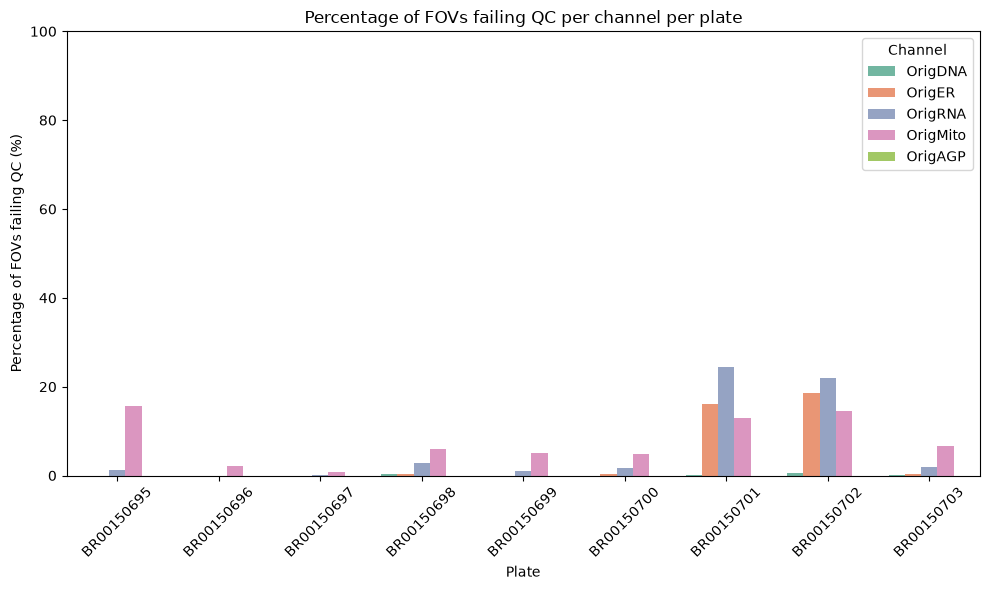

In [17]:
# List of channels to check
channels = ["OrigDNA", "OrigER", "OrigRNA", "OrigMito", "OrigAGP"]
percentmax_cols = [f"ImageQuality_PercentMaximal_{ch}" for ch in channels]

# Make sure PercentMaximal columns are numeric
for col in percentmax_cols:
    if col in orig_df.columns:
        orig_df[col] = pd.to_numeric(orig_df[col], errors="coerce")

# Compute percentage failing per channel per plate
fail_summary = []
for plate, plate_df in orig_df.groupby("Metadata_Plate"):
    total_fovs = len(plate_df)
    for ch, col in zip(channels, percentmax_cols):
        num_fail = (plate_df[col] >= 1).sum()
        pct_fail = num_fail / total_fovs * 100
        fail_summary.append(
            {"Metadata_Plate": plate, "Channel": ch, "PctFail": pct_fail}
        )

fail_df = pd.DataFrame(fail_summary)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=fail_df, x="Metadata_Plate", y="PctFail", hue="Channel", palette="Set2"
)
plt.ylabel("Percentage of FOVs failing QC (%)")
plt.xlabel("Plate")
plt.title("Percentage of FOVs failing QC per channel per plate")
plt.legend(title="Channel")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Generate overall plot with how many FOVs failed QC in general

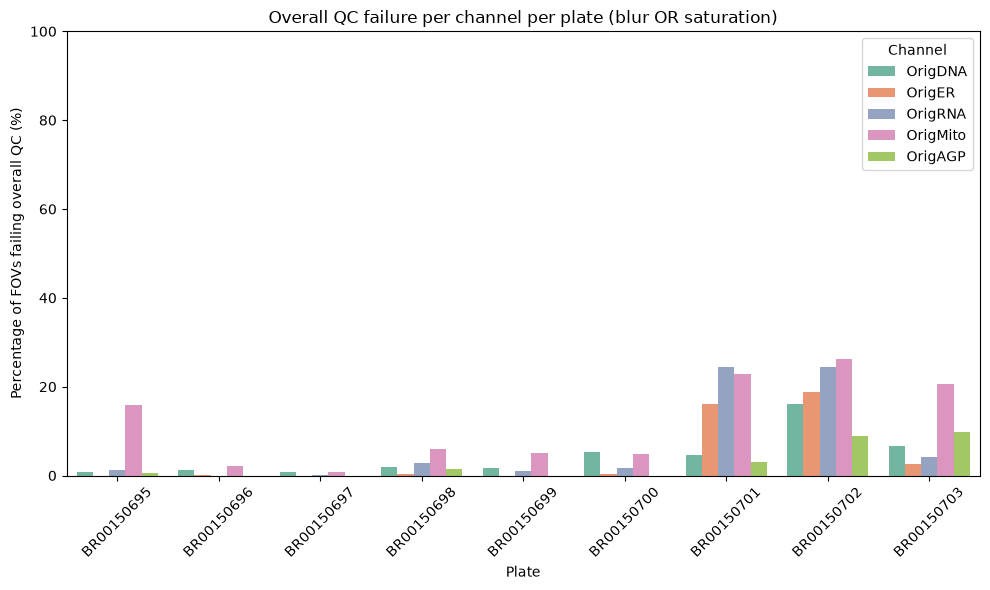

In [18]:
# List of channels
channels = ["OrigDNA", "OrigER", "OrigRNA", "OrigMito", "OrigAGP"]

# Ensure numeric columns
for ch in channels:
    blur_col = f"ImageQuality_PowerLogLogSlope_{ch}"
    sat_col = f"ImageQuality_PercentMaximal_{ch}"
    if blur_col in orig_df.columns:
        orig_df[blur_col] = pd.to_numeric(orig_df[blur_col], errors="coerce")
    if sat_col in orig_df.columns:
        orig_df[sat_col] = pd.to_numeric(orig_df[sat_col], errors="coerce")

# Compute overall % FOVs failing per channel per plate
fail_summary = []

for plate, plate_df in orig_df.groupby("Metadata_Plate"):
    total_fovs = len(plate_df)
    for ch in channels:
        blur_col = f"ImageQuality_PowerLogLogSlope_{ch}"
        sat_col = f"ImageQuality_PercentMaximal_{ch}"
        blur_thresh = raw_thresholds.get(ch, 0)  # default 0 if missing
        sat_thresh = 1  # or whichever % threshold you want for saturation

        # FOV fails if below blur threshold OR above saturation threshold
        fail_mask = (plate_df[blur_col] < blur_thresh) | (
            plate_df[sat_col] >= sat_thresh
        )
        num_fail = fail_mask.sum()
        pct_fail = num_fail / total_fovs * 100

        fail_summary.append(
            {"Metadata_Plate": plate, "Channel": ch, "PctFail": pct_fail}
        )

fail_df = pd.DataFrame(fail_summary)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=fail_df, x="Metadata_Plate", y="PctFail", hue="Channel", palette="Set2"
)
plt.ylabel("Percentage of FOVs failing overall QC (%)")
plt.xlabel("Plate")
plt.title("Overall QC failure per channel per plate (blur OR saturation)")
plt.legend(title="Channel")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## View example oversaturated FOVs across all channels

We visualize example FOVs that fail the oversaturation threshold (≥1% of pixels at the max intensity) for each channel.


=== OrigDNA: 9 oversaturated FOVs ===


,FileName_OrigDNA,ImageQuality_PercentMaximal_OrigDNA
1830,,5.603738
6004,,2.856481
6016,,1.284379
6010,,2.730024
4845,,2.867112

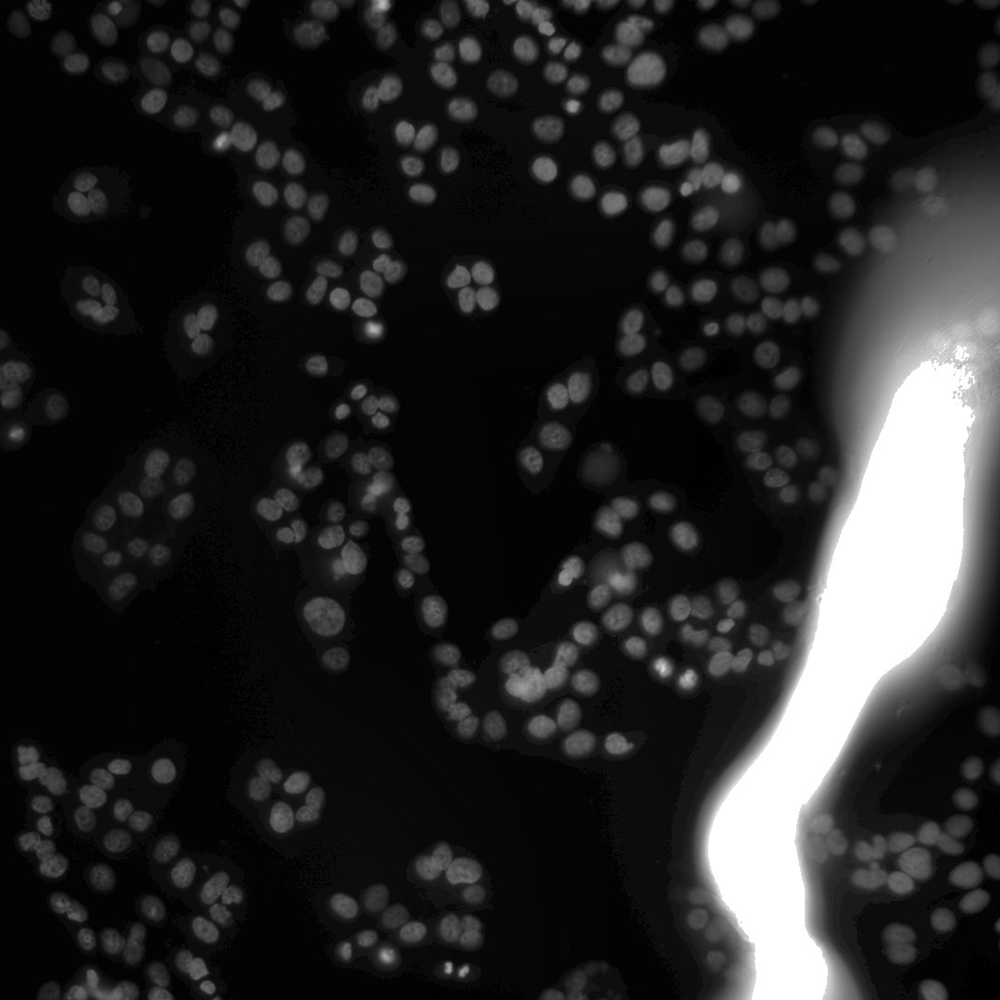
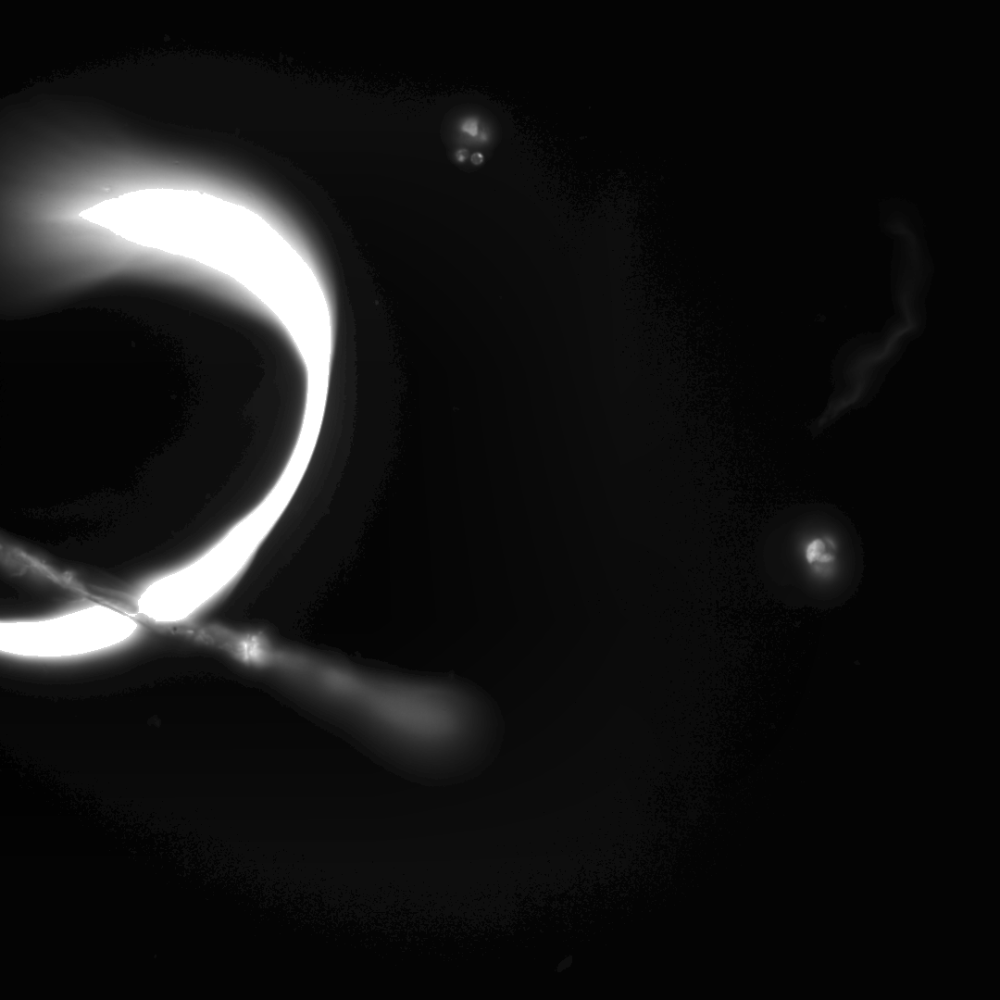
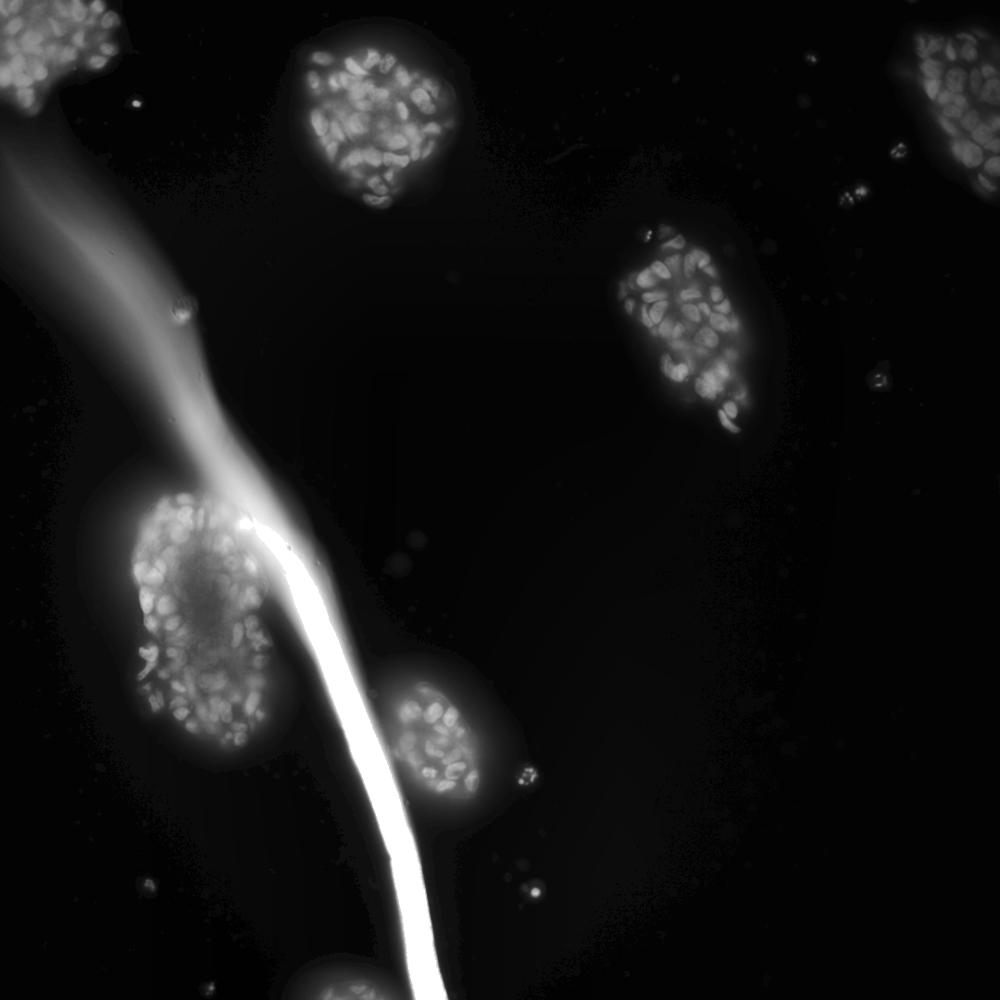
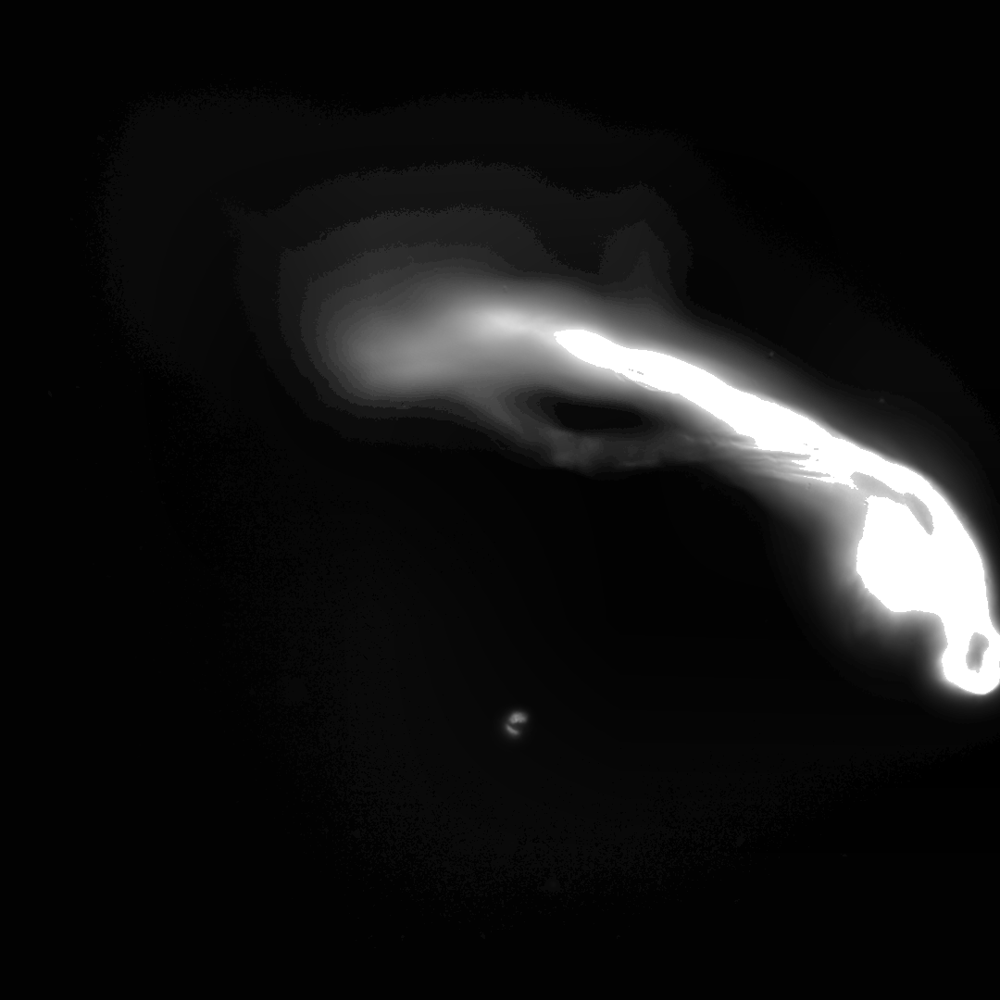
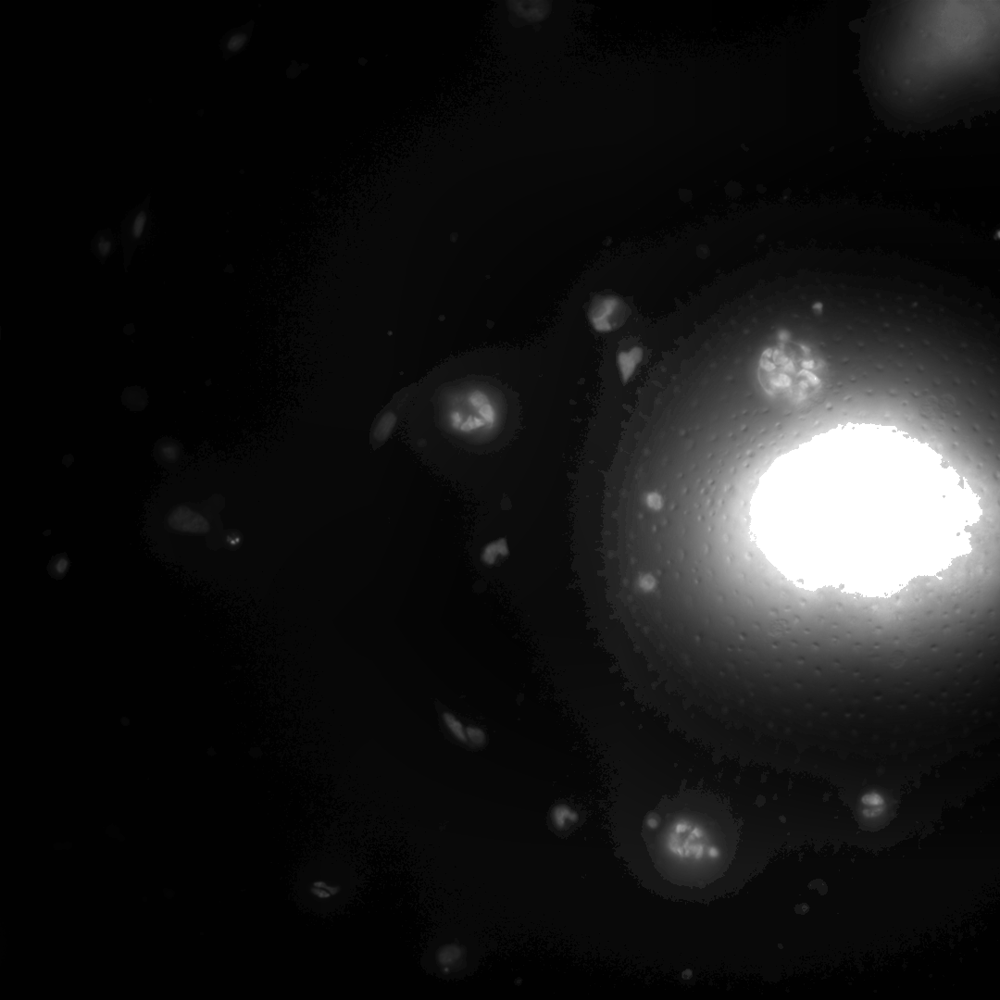


=== OrigER: 381 oversaturated FOVs ===


,FileName_OrigER,ImageQuality_PercentMaximal_OrigER
1692,,2.749228
1981,,1.181670
1702,,1.543981
5678,,3.385974
5925,,2.697960

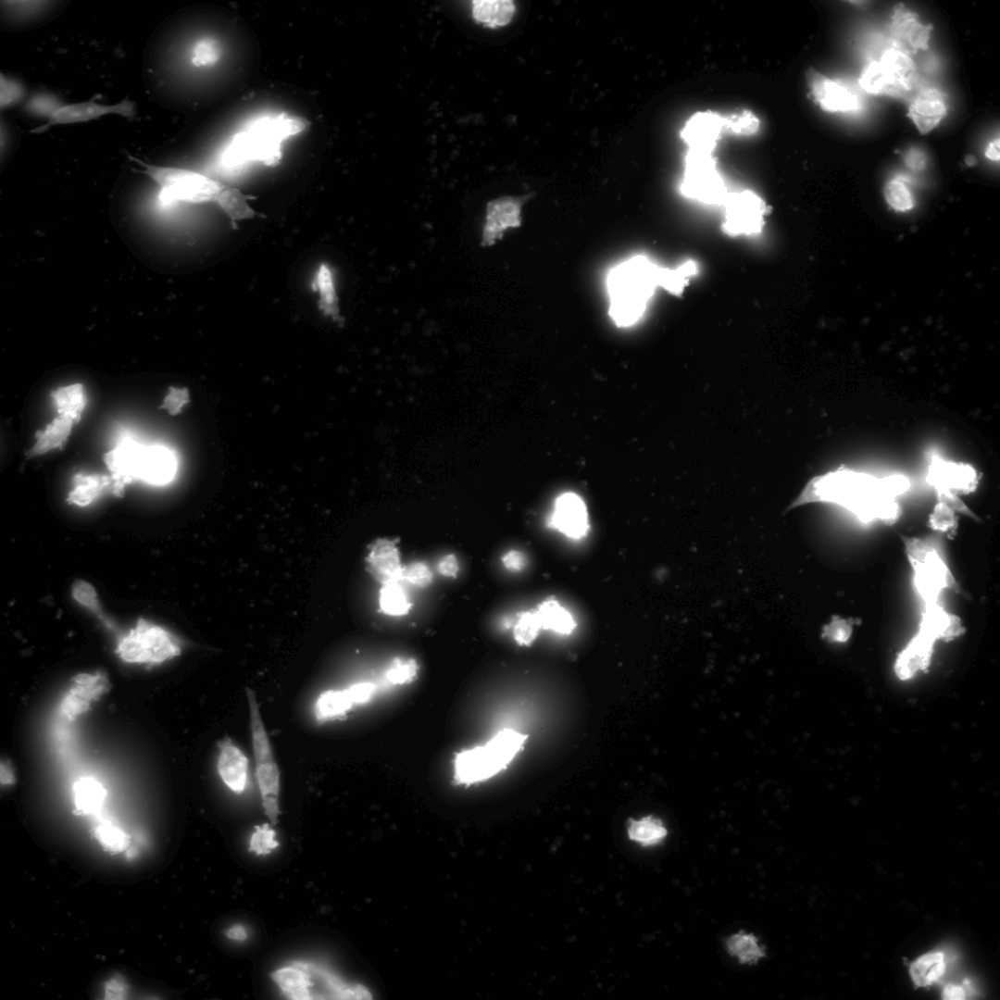
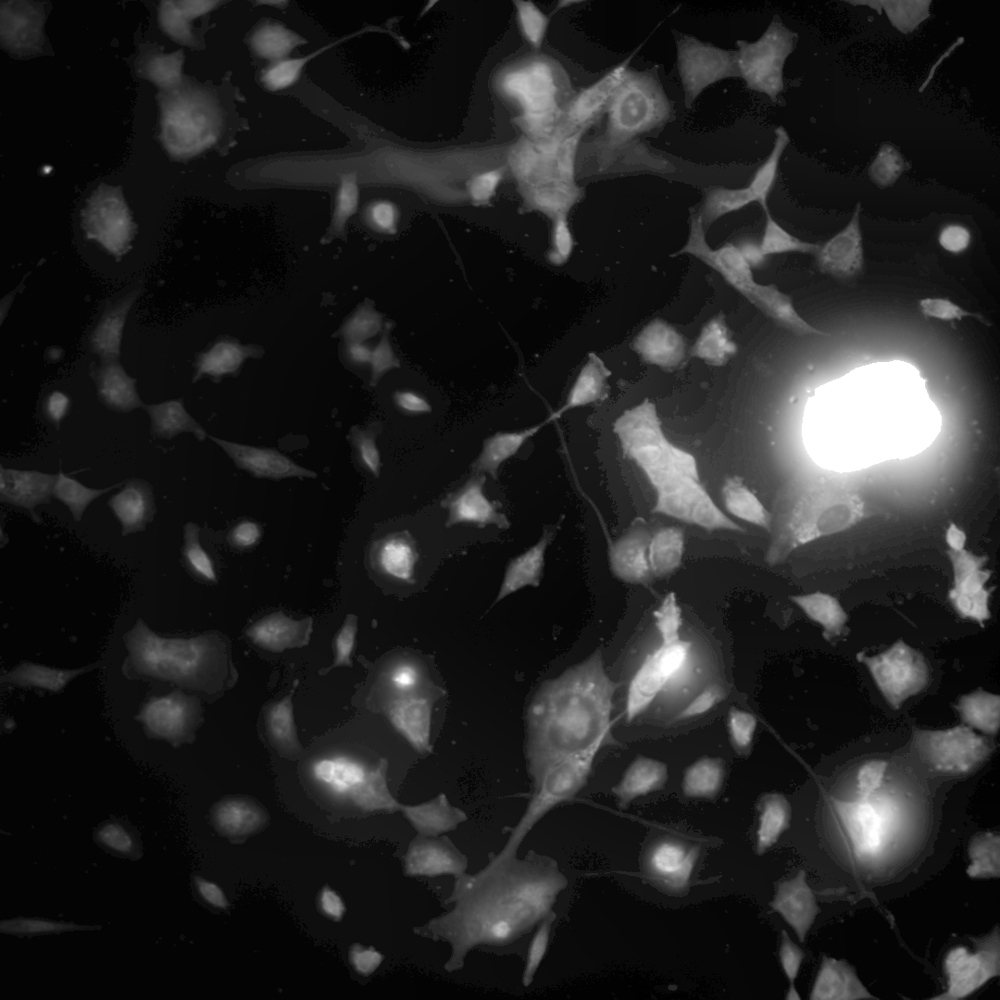
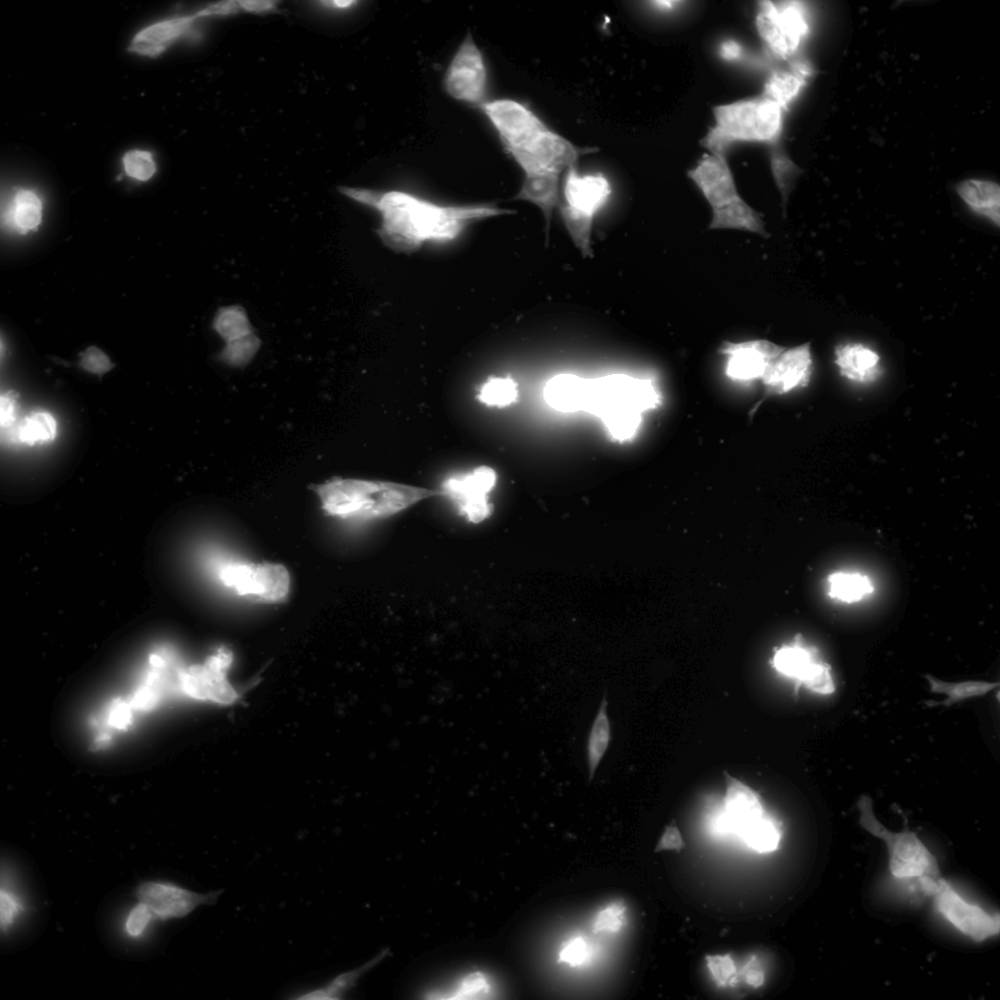
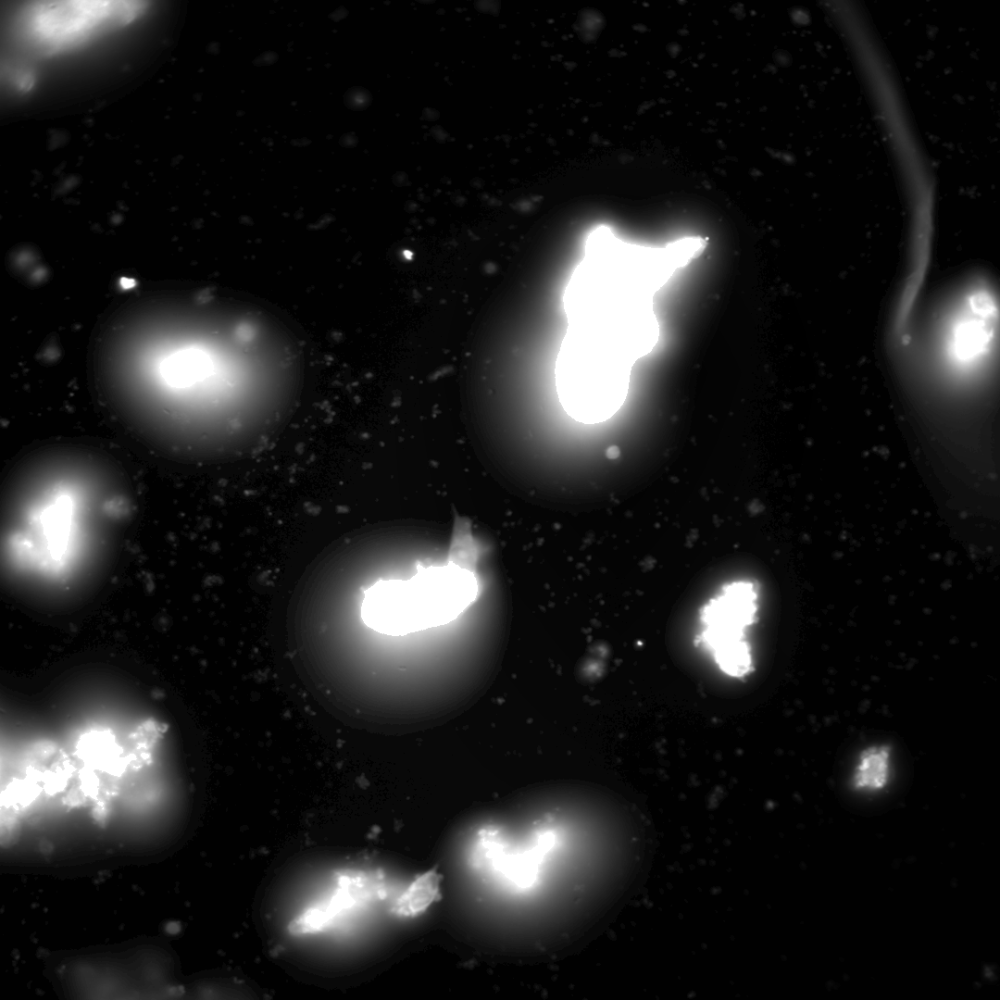
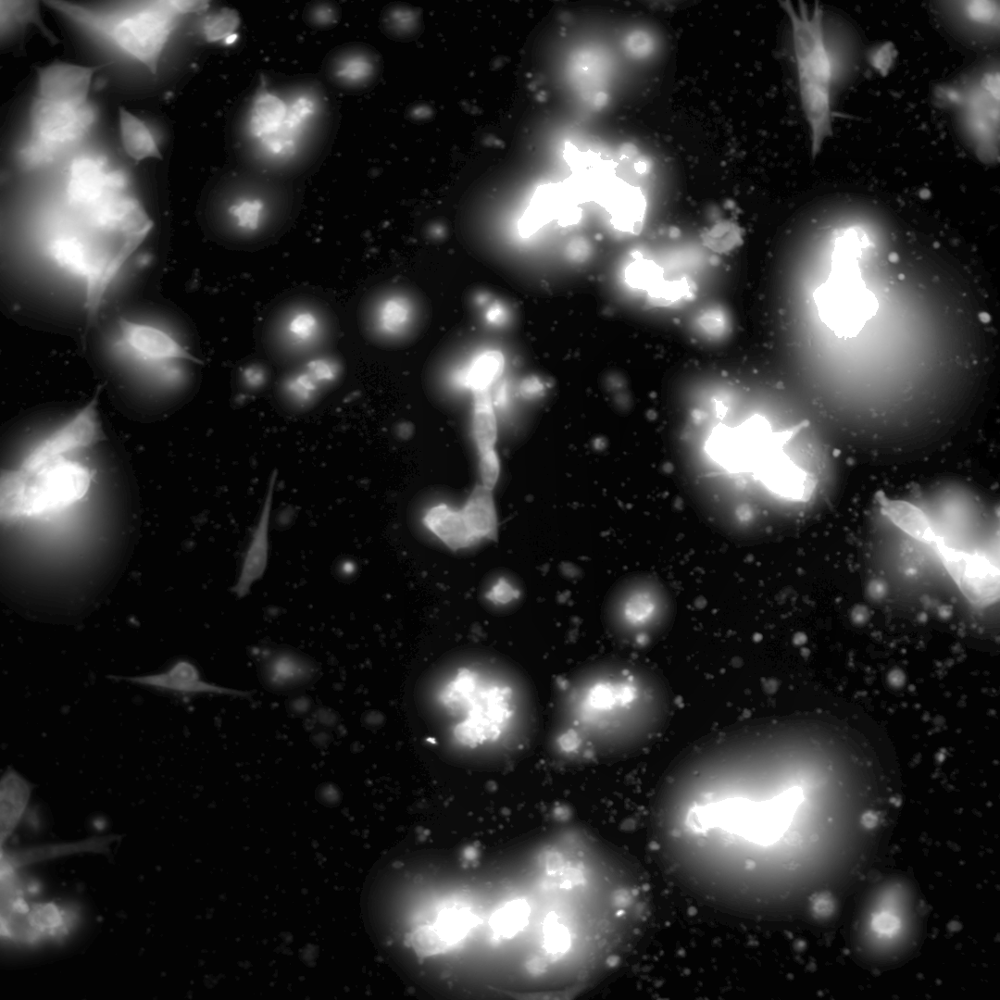


=== OrigRNA: 578 oversaturated FOVs ===


,FileName_OrigRNA,ImageQuality_PercentMaximal_OrigRNA
1965,,1.148320
6013,,4.974366
1700,,3.581704
1019,,1.353909
6021,,1.824074

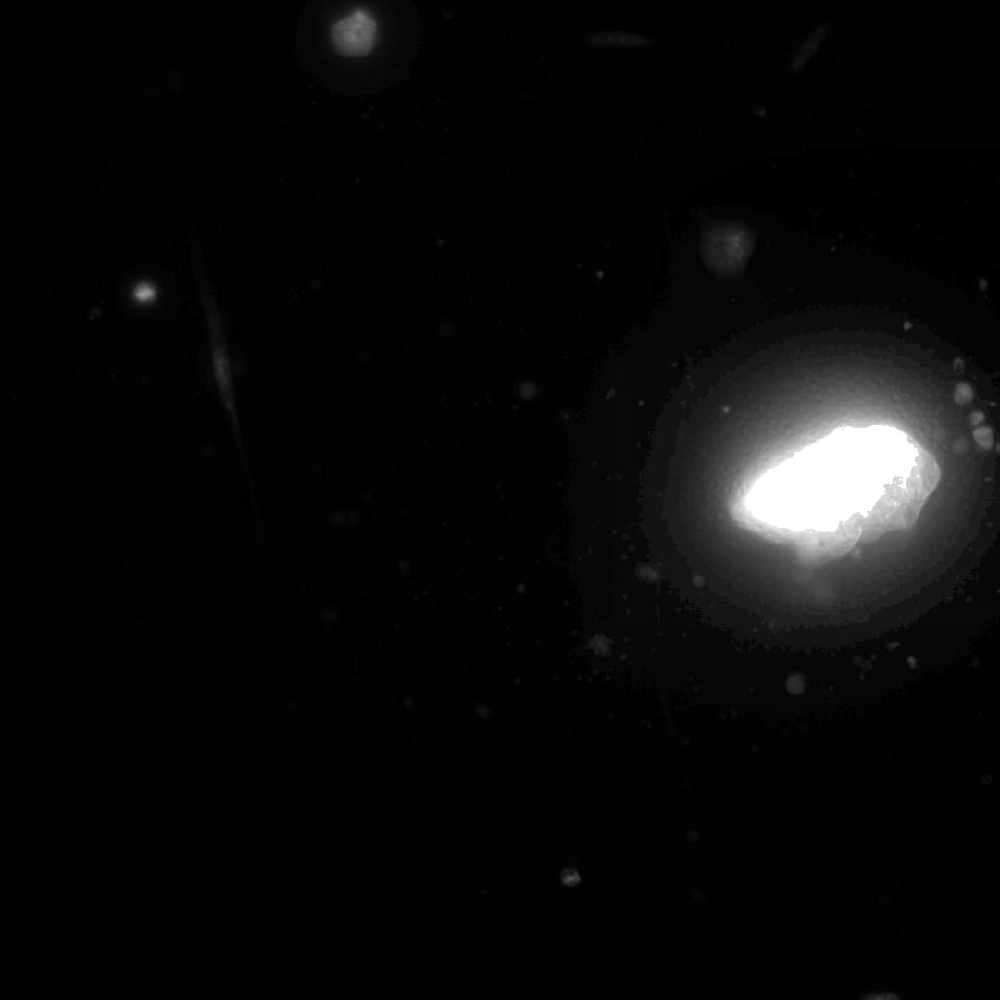
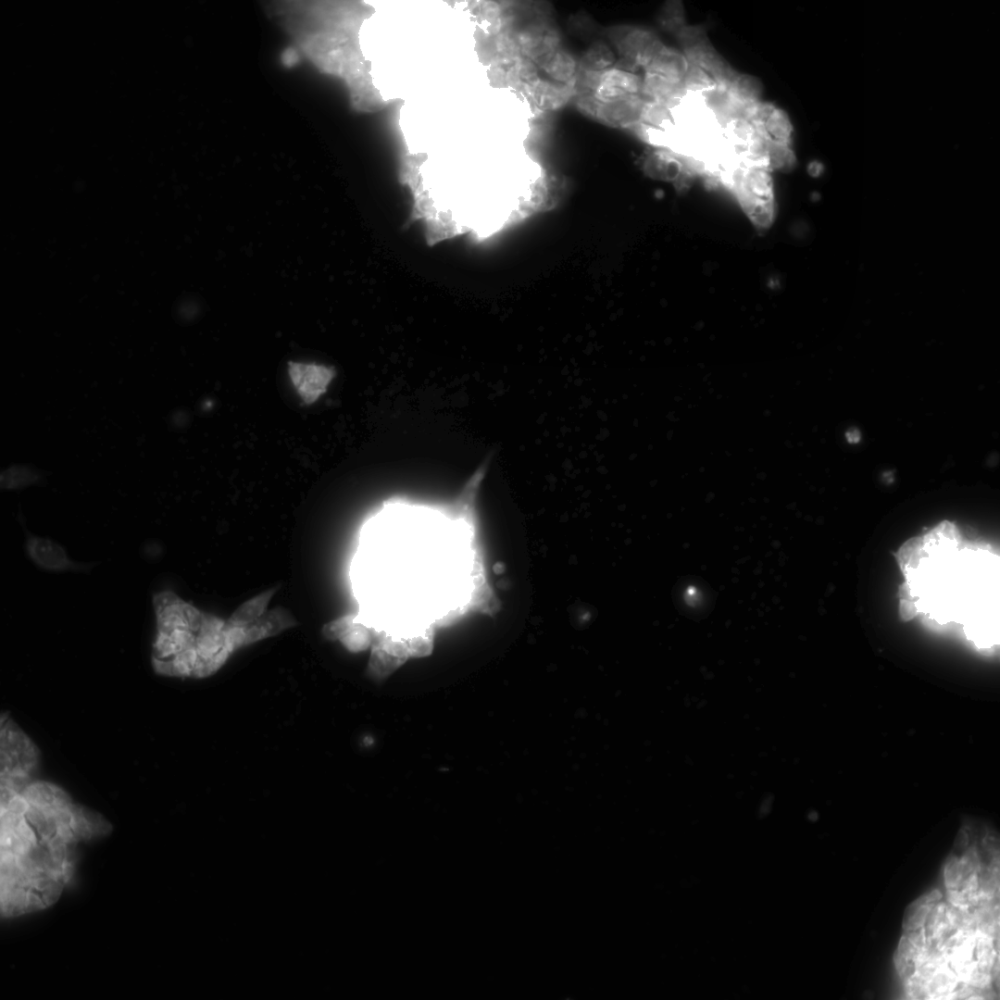
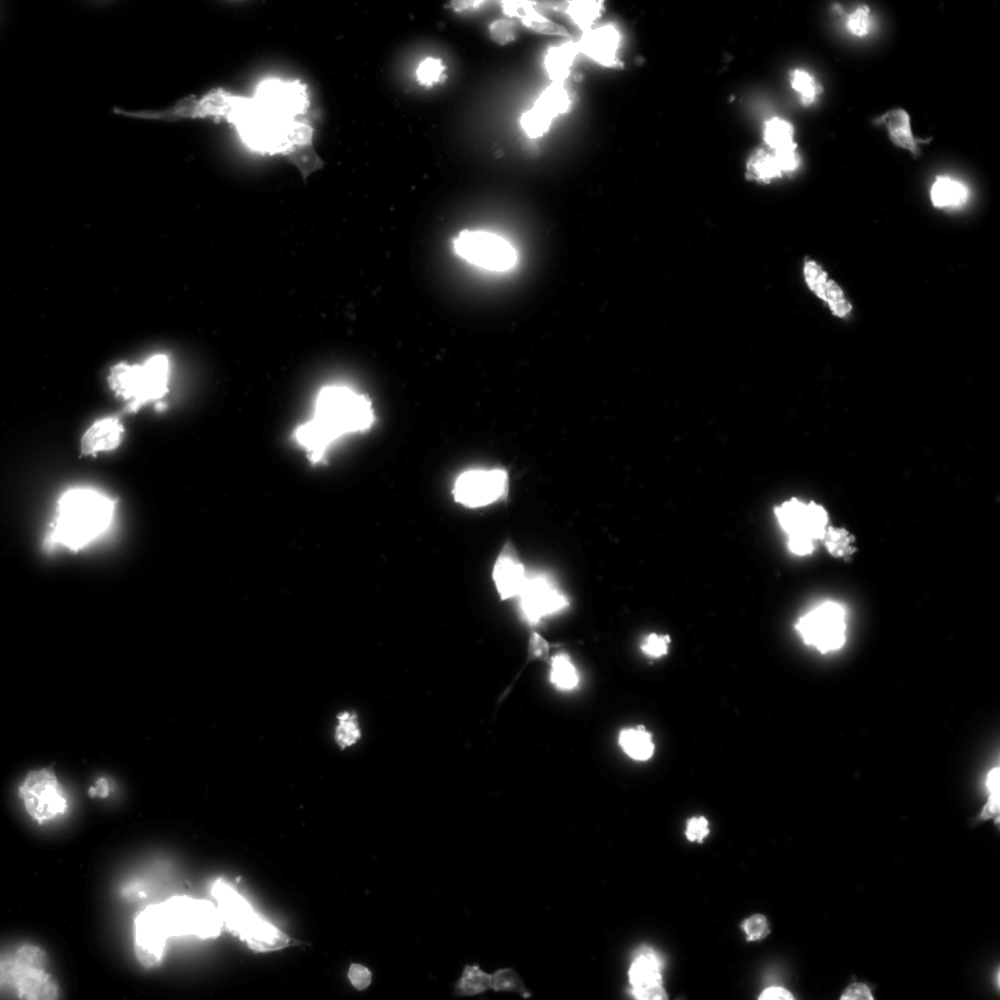
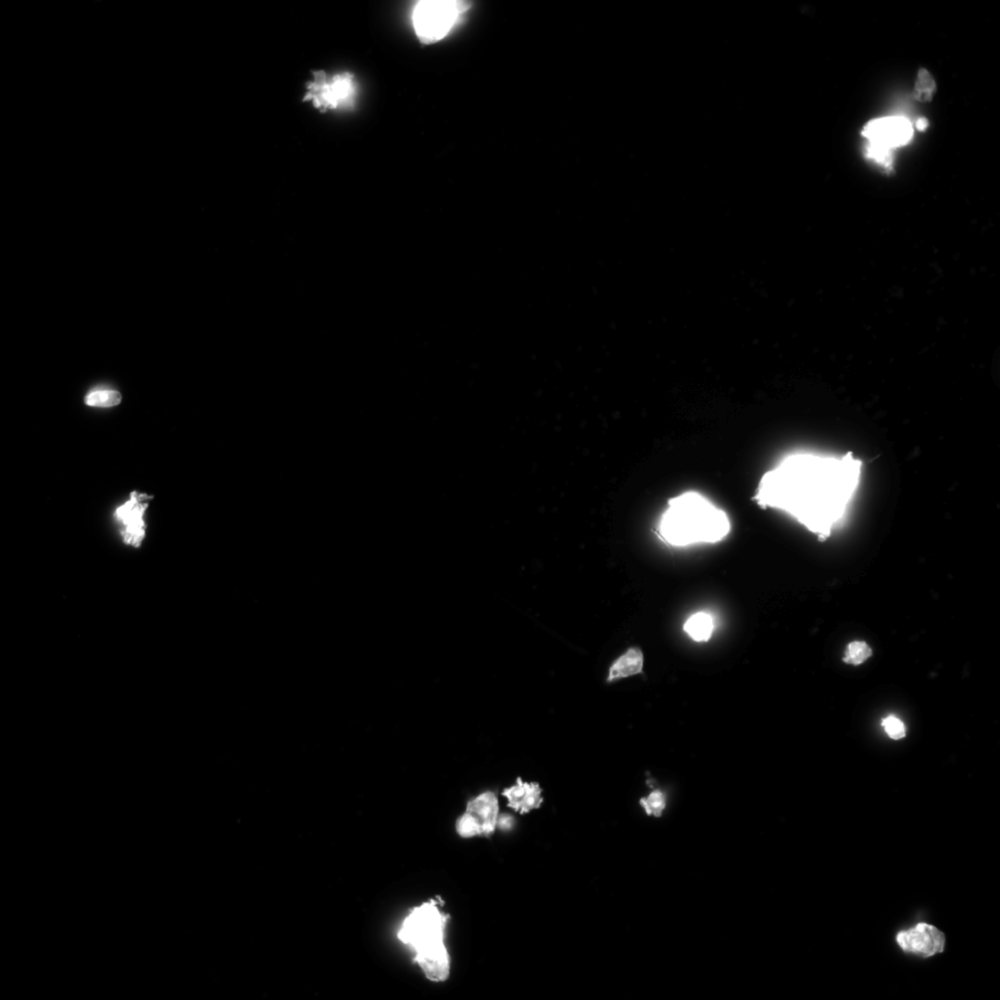
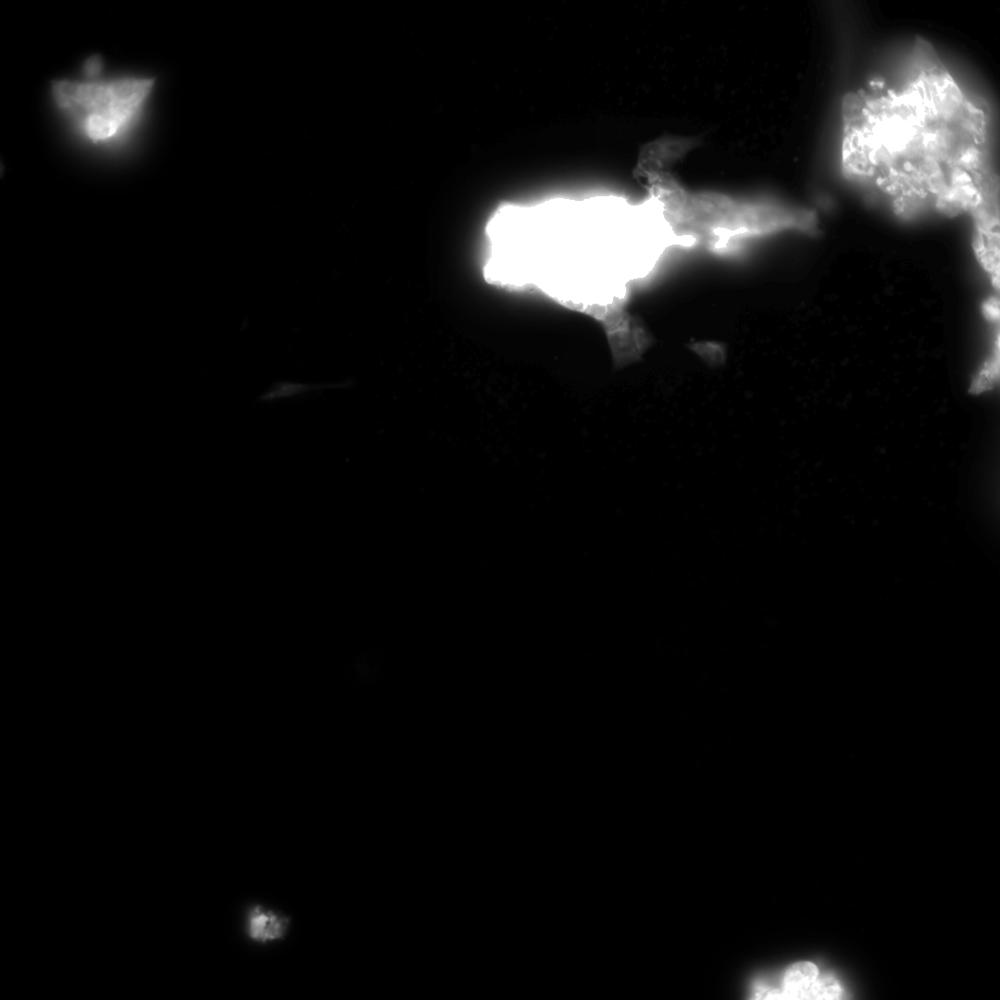


=== OrigMito: 667 oversaturated FOVs ===


,FileName_OrigMito,ImageQuality_PercentMaximal_OrigMito
2953,,1.282150
2040,,2.490998
4854,,1.373885
1697,,1.874228
27,,23.608025

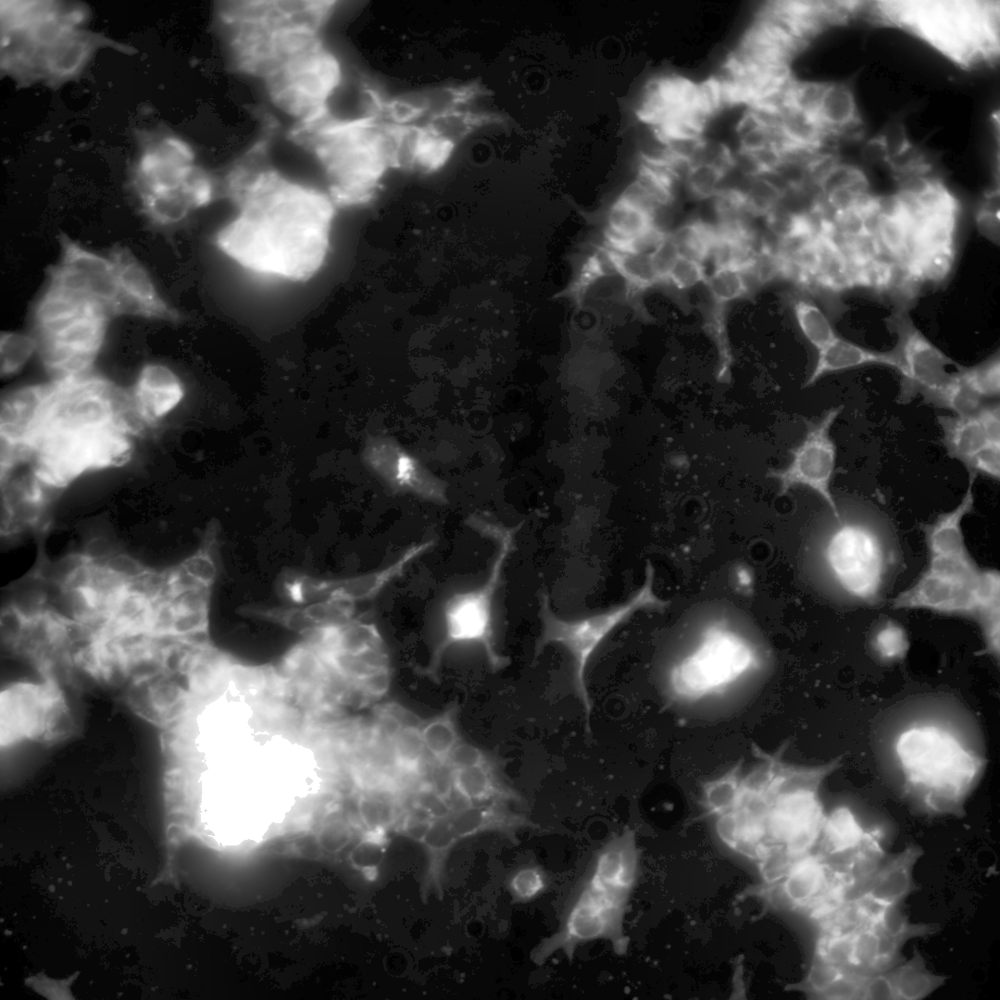
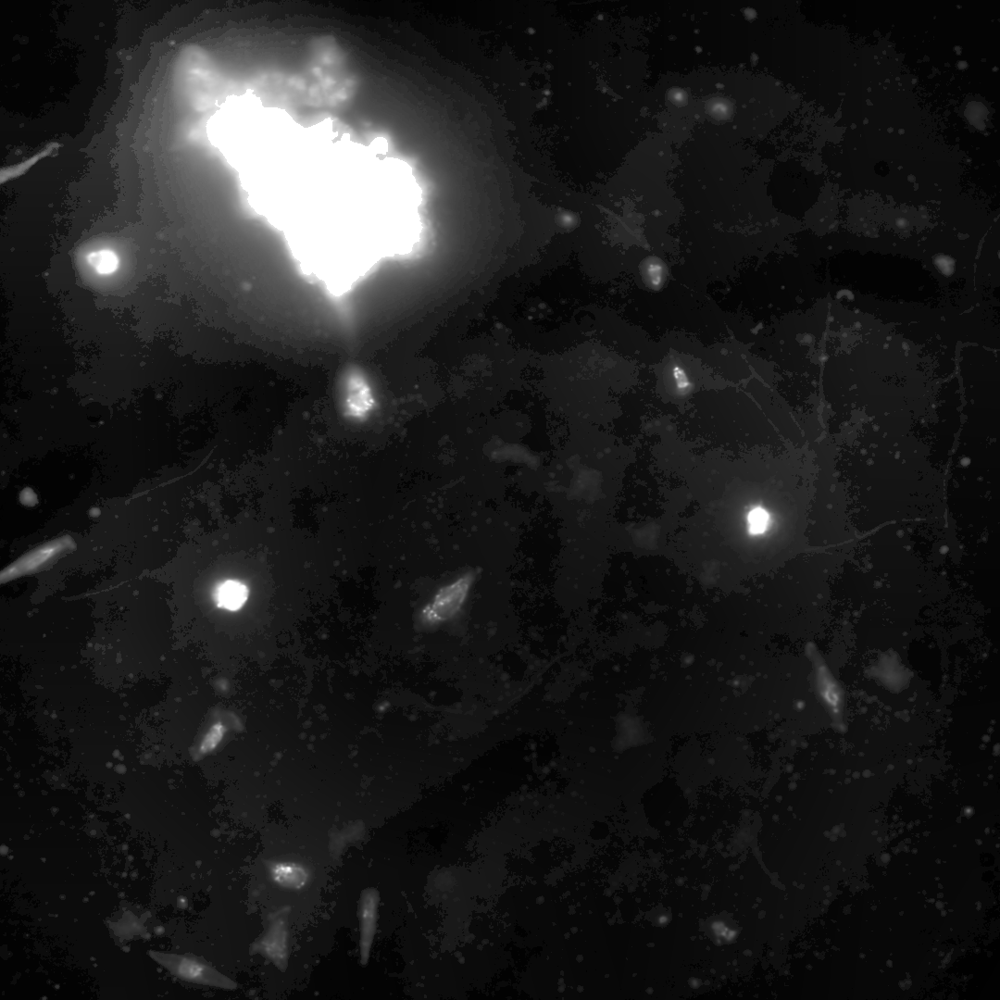
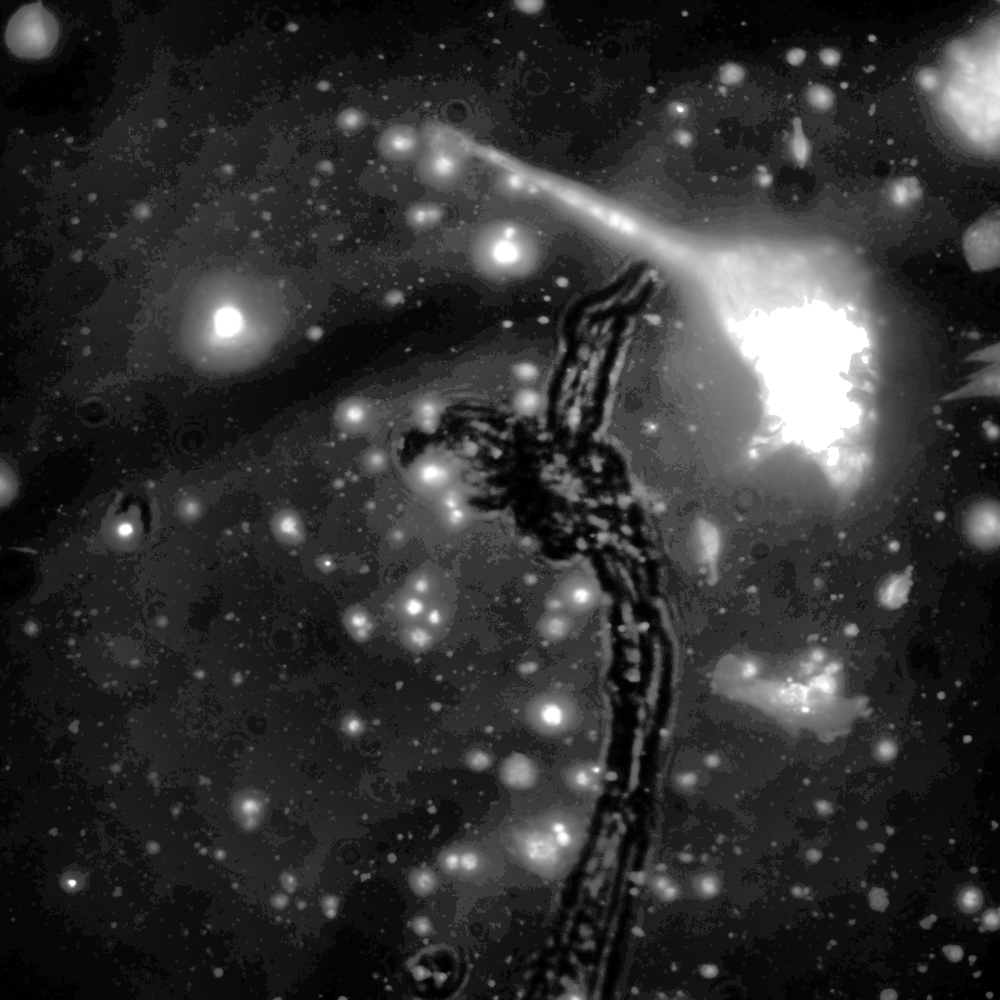
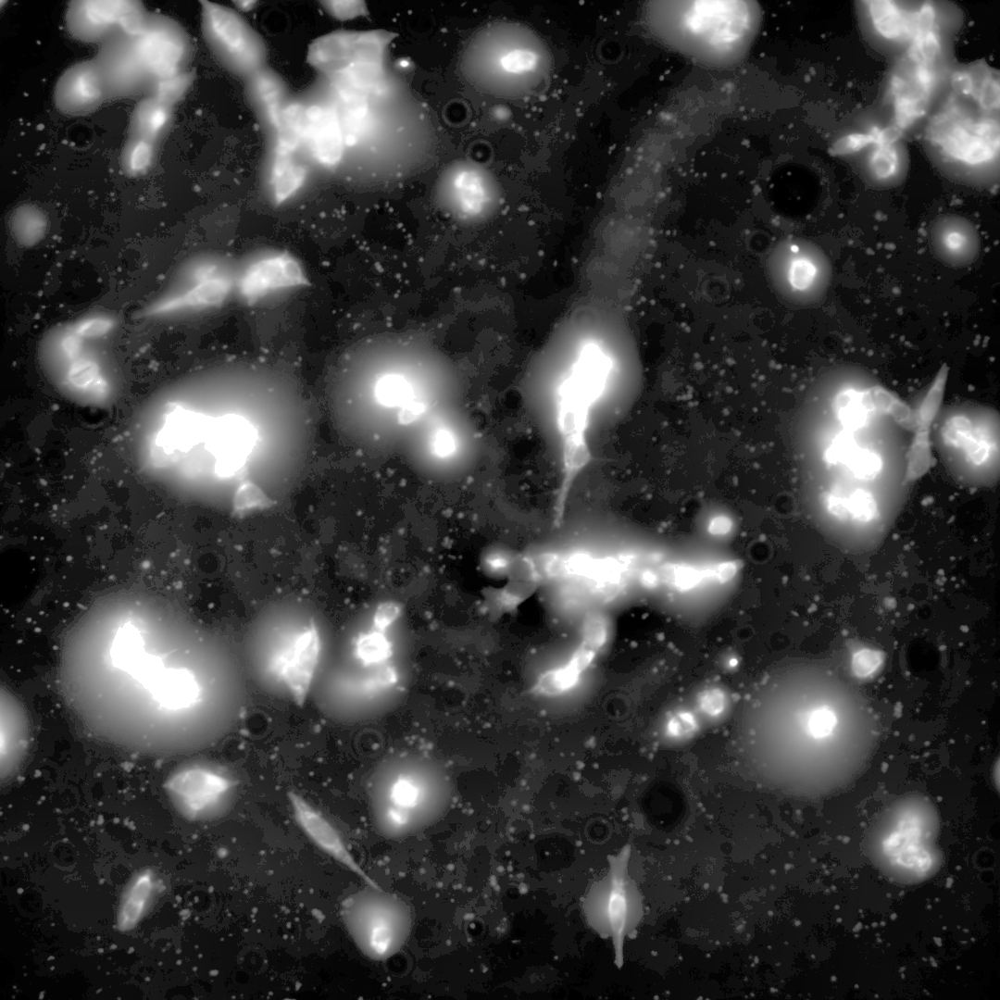
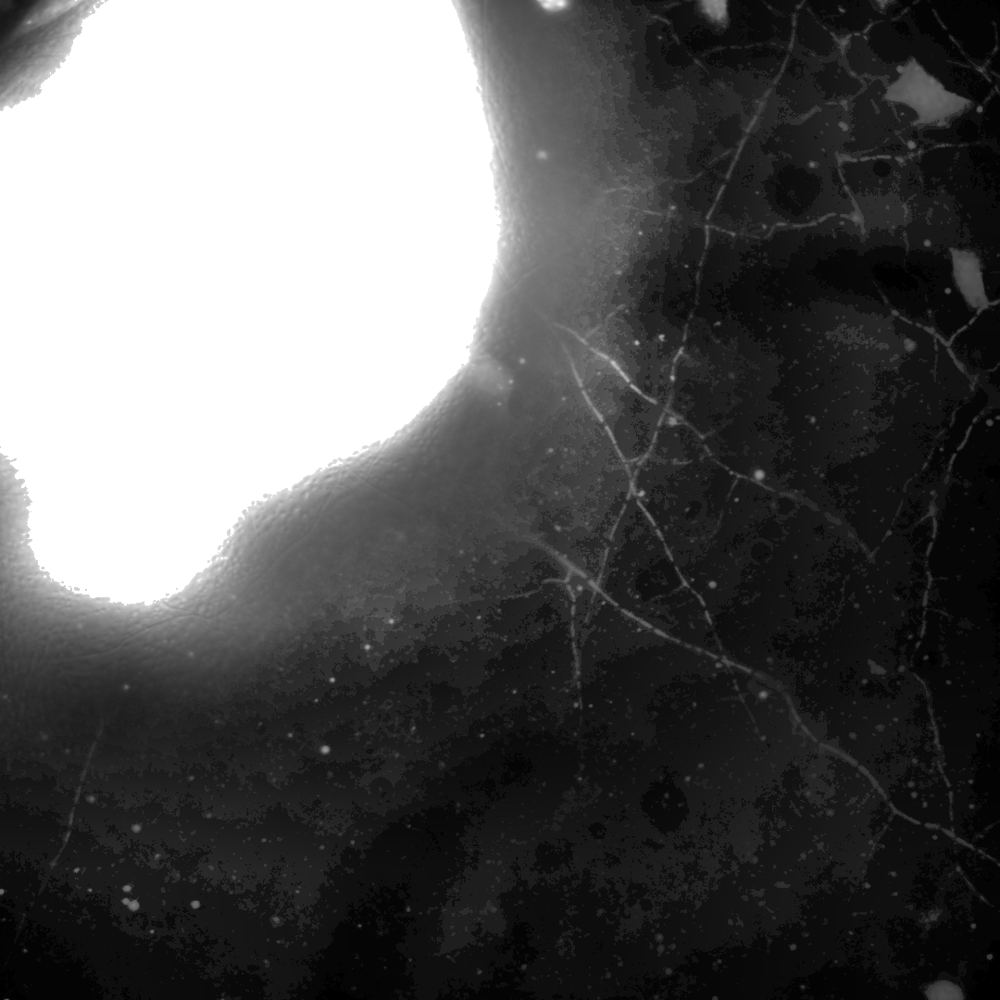


=== OrigAGP: 0 oversaturated FOVs ===


In [19]:
# List of channels to check for oversaturation
channels = ["OrigDNA", "OrigER", "OrigRNA", "OrigMito", "OrigAGP"]

# Loop through each channel and view example oversaturated FOVs
for channel in channels:
    percentmax_col = f"ImageQuality_PercentMaximal_{channel}"
    filename_col = f"FileName_{channel}"
    pathname_col = f"PathName_{channel}"

    # Find oversaturated FOVs for this channel (>=1% of pixels at max intensity)
    oversaturated_channel_outliers = orig_df.loc[
        orig_df[percentmax_col] >= 1,
        metadata_columns + [percentmax_col, filename_col, pathname_col],
    ]

    print(
        f"\n=== {channel}: {len(oversaturated_channel_outliers)} oversaturated FOVs ==="
    )

    if oversaturated_channel_outliers.empty:
        continue

    # Convert the outlier data frame into a CytoDataFrame so we can view FOVs
    oversaturated_outliers_cdf = CytoDataFrame(
        oversaturated_channel_outliers,
        display_options={"render_whole_image": True, "brightness": 1},
    )

    # Display example oversaturated FOVs that failed QC.
    display(
        oversaturated_outliers_cdf[[filename_col, percentmax_col]]
        .sort_values(percentmax_col, ascending=False)
        .sample(min(5, len(oversaturated_outliers_cdf)))
    )
